# Estimación de los hiperparámetros del PID proporcional mediante K vecinos más cercanos

Esta libreta parte del archivo `SINTONIZACIONES.csv`, generado en la libreta previa mediante Algoritmo Genético, y desarrolla el siguiente procedimiento:

1. **Conformación de los conjuntos.** Los registros cuyo RMSE constituye un valor atípico superior, de acuerdo con el criterio de Tukey ($\mathrm{RMSE} > Q_3 + 1.5\,\mathrm{RIC}$), se descartan y se reservan como *datos de validación*. Con los restantes se conforma el **Espacio** de referencia, integrado por los pacientes de menor error y equilibrado al 50 % entre hombres y mujeres; los pacientes no seleccionados constituyen los *datos de estimación*.

2. **Estimación por K vecinos más cercanos.** Los hiperparámetros se estiman como combinación lineal de los correspondientes a los K vecinos más próximos, empleando como pesos los inversos de las distancias de Minkowski transformados mediante la función softmax. La estimación final se acota, parámetro a parámetro, al intervalo de búsqueda empleado por el Algoritmo Genético.

3. **Función de error ξ.** El desempeño se cuantifica mediante

$$\xi \;=\; \frac{2}{T_c^{2}}\int_{0}^{T_c} t\,\left|\frac{e(t)}{\Lambda(t)}\right|\,dt$$

donde $e(t)=\mathrm{BIS}(t)-\Lambda(t)$, $\Lambda(t)$ es la trayectoria de sedación, mantenimiento y recuperación, y $T_c$ es la duración conjunta de las fases de sedación y mantenimiento. Durante la fase de recuperación, de 30 minutos, el controlador se desactiva y la planta evoluciona en lazo abierto, por lo que dicha fase no interviene en $\xi$, en concordancia con la función de costo empleada en la sintonización poblacional. El factor $2/T_c^{2}$ hace que $\xi$ sea adimensional e interpretable como error relativo medio ponderado en el tiempo.


## Etapa 1: Configuración del entorno

In [1]:
# =============================================================================
# CONFIGURACIÓN GLOBAL 
# =============================================================================

# ── Rutas ─────────────────────────────────────────────────────────────────────
RUTA_MODELO          = r"C:\Users\yordi\Desktop\modeloBIS.pt"
RUTA_GRAFICAS        = r"C:\Users\yordi\Desktop"
RUTA_SINTONIZACIONES = "SINTONIZACIONES.csv"   # Archivo generado en la libreta previa

# ── Rangos de normalización del modelo predictor del BIS ──────────────────────
# (fijos, correspondientes al preprocesamiento con el que fue entrenado)
EDAD_MIN, EDAD_MAX     = 16.00, 90.00
PESO_MIN, PESO_MAX     = 34.10, 112.80
ALTURA_MIN, ALTURA_MAX = 140.20, 186.60

# =============================================================================
# IMPORTACIONES
# =============================================================================
import os, time, math, sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from scipy import stats
from Modelo_Predictor_BIS import ModeloAnestesia
from Normalizacion_BIS import (cargar_estadisticas, describir_estadisticas,
                               construir_ventanas_simulacion)

# Estadísticas globales de normalización, calculadas sobre el conjunto de
# entrenamiento por Crea_tensores_pytorch.ipynb; deben ser las mismas con
# las que se entrenó el modelo predictor
ESTADISTICAS = cargar_estadisticas()
print("[INFO] Estadísticas de normalización:")
print(describir_estadisticas(ESTADISTICAS))

# =============================================================================
# DISPOSITIVO Y CARGA DEL MODELO PREDICTOR DEL BIS
# =============================================================================
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo : {dispositivo}")
if dispositivo.type == "cuda":
    print(f"[INFO] GPU         : {torch.cuda.get_device_name(0)}")

modelo = ModeloAnestesia().to(dispositivo)
modelo.load_state_dict(
    torch.load(RUTA_MODELO, map_location=dispositivo, weights_only=True)
)
modelo.eval()
for p in modelo.parameters():
    p.requires_grad_(False)

print(f"[INFO] Modelo cargado — "
      f"{sum(p.numel() for p in modelo.parameters()):,} parámetros")


# =============================================================================
# NORMALIZACIÓN DE LAS COVARIABLES PARA EL MODELO PREDICTOR DEL BIS
# =============================================================================
# NOTA: esta normalización corresponde al preprocesamiento fijo del modelo
# predictor del BIS y es independiente de la normalización min-max que se
# aplicará posteriormente para el algoritmo de K vecinos más cercanos.

def normalizar_paciente(edad, peso, altura, sexo=0):
    """
    Convierte las características fisiológicas del paciente a los valores
    normalizados que espera el modelo predictor del BIS.

    Parámetros
    ----------
    edad, peso, altura : valores en unidades naturales (años, kg, cm)
    sexo               : 0 = masculino, 1 = femenino

    Retorna
    -------
    Tupla (edad_n, peso_n, altura_n, sexo_n)
    """
    return (
        (edad   - EDAD_MIN)   / (EDAD_MAX   - EDAD_MIN),
        (peso   - PESO_MIN)   / (PESO_MAX   - PESO_MIN),
        (altura - ALTURA_MIN) / (ALTURA_MAX - ALTURA_MIN),
        float(sexo),
    )


def hacer_cov_lote(df_pac: pd.DataFrame) -> torch.Tensor:
    """
    Construye un tensor de covariables (N, 4) a partir de un DataFrame de
    pacientes, lo que permite simular a toda una cohorte en un único lote,
    asignando a cada paciente sus propias características fisiológicas.

    Parámetros
    ----------
    df_pac : DataFrame con las columnas Edad, Peso, Altura y Sexo_num

    Retorna
    -------
    torch.Tensor de forma (N, 4) en el dispositivo activo
    """
    filas = [
        normalizar_paciente(float(f["Edad"]), float(f["Peso"]),
                             float(f["Altura"]), int(f["Sexo_num"]))
        for _, f in df_pac.iterrows()
    ]
    return torch.tensor(filas, dtype=torch.float32, device=dispositivo)


[INFO] Estadísticas de normalización:
  propofol      : media = 0.00512937, desviación estándar = 0.00783327
  remifentanilo : media = 0.00602943, desviación estándar = 0.00732605
  bis           : media = 44.9932, desviación estándar = 12.6622
[INFO] Dispositivo : cuda
[INFO] GPU         : NVIDIA GeForce RTX 5060
[INFO] Modelo cargado — 144,212 parámetros


## Etapa 2: Filtro de señales, trayectoria Λ(t) y función de error ξ

In [2]:
# =============================================================================
# FILTRO DE MEDIA EXPONENCIAL MÓVIL, TRAYECTORIA Y FUNCIÓN DE ERROR
# =============================================================================

# ── Hiperparámetros del filtro de media exponencial móvil ────────────────────
# Antes de introducirse al modelo predictor del BIS, las señales de control se
# filtran mediante una media exponencial móvil aplicada sobre una ventana
# deslizante de longitud fija, rellenada con ceros en su parte inicial:
#
#       y[n] = α · u[n] + (1 − α) · y[n − 1]
#
# Los valores coinciden con los empleados en la sintonización poblacional
# (PID_Filtro_EMA.ipynb), con la que se generó SINTONIZACIONES.csv.
VENTANA_EMA = 12      # ← Longitud de la ventana deslizante
ALFA_EMA    = 0.05    # ← Factor de suavizado α


def construir_pesos_ema(ventana: int = VENTANA_EMA,
                         alfa: float = ALFA_EMA) -> torch.Tensor:
    """
    Construye el vector de pesos equivalente a la recursión de la media
    exponencial móvil sobre una ventana de longitud fija.

    Al reinicializarse la recursión con y[−1] = 0 al comienzo de cada ventana,
    la media exponencial móvil resulta ser una combinación lineal fija de las
    muestras contenidas en dicha ventana:

        y = Σ_{k=0}^{V−1}  α · (1 − α)^(V − 1 − k) · x[k]

    Expresarla de esta forma permite evaluarla mediante un único producto
    matricial, en lugar de un bucle recursivo, lo que reduce sustancialmente
    el tiempo de cómputo sin alterar en absoluto el resultado numérico.

    Parámetros
    ----------
    ventana : longitud de la ventana deslizante
    alfa    : factor de suavizado

    Retorna
    -------
    torch.Tensor de forma (ventana,) con los pesos del filtro
    """
    k = torch.arange(ventana, dtype=torch.float32, device=dispositivo)
    return alfa * (1.0 - alfa) ** (ventana - 1 - k)


@torch.no_grad()
def filtro_ema_ventana(buffer_crudo: torch.Tensor, t: int,
                        pesos_ema: torch.Tensor) -> torch.Tensor:
    """
    Calcula el valor filtrado en el instante t para todo el lote en paralelo.

    La ventana se conforma con las últimas V muestras de la señal cruda,
    completando con ceros las posiciones para las cuales aún no existe
    historial.

    Parámetros
    ----------
    buffer_crudo : (N, T_sim) — historial de la señal cruda de control
    t             : instante actual
    pesos_ema     : (V,) — pesos del filtro

    Retorna
    -------
    (N,) — valor filtrado en el instante t
    """
    N, V = buffer_crudo.shape[0], pesos_ema.shape[0]
    ini  = max(0, t - V + 1)
    fin  = t + 1
    n_relleno = V - (fin - ini)

    if n_relleno > 0:
        ceros = torch.zeros(N, n_relleno, device=buffer_crudo.device)
        ventana_datos = torch.cat([ceros, buffer_crudo[:, ini:fin]], dim=1)
    else:
        ventana_datos = buffer_crudo[:, ini:fin]

    return ventana_datos @ pesos_ema


# =============================================================================
# VENTANAS DE ENTRADA DEL MODELO PREDICTOR
# =============================================================================
# Las ventanas se construyen mediante construir_ventanas_simulacion, definida
# en Normalizacion_BIS.py, que aplica el mismo relleno y la misma
# normalización global empleados en el entrenamiento del modelo.


# =============================================================================
# TRAYECTORIA DE REFERENCIA Λ(t)  (SEDACIÓN · MANTENIMIENTO · RECUPERACIÓN)
# =============================================================================
#   Fase 1 — Sedación      (   0 –  300 s): Λ(t) = 98 + 56.8·tanh(−0.004·t)
#   Fase 2 — Mantenimiento ( 300 – 3900 s): Λ(t) = 50  (constante)
#   Fase 3 — Recuperación  (3900 – 5700 s): Λ(t) = 50 + 42·tanh(0.003·(t−3900))
#
# El PID opera en lazo cerrado durante las fases de sedación y mantenimiento.
# Al iniciar la fase de recuperación, el controlador se desactiva y la señal de
# control se anula, de modo que la planta evoluciona en lazo abierto durante
# 30 minutos; en esta fase Λ(t) se conserva únicamente como curva de
# comparación. La configuración coincide con la de la sintonización
# poblacional (PID_Filtro_EMA.ipynb).

T_SEDACION      = 300     # [s]
T_MANTENIMIENTO = 3600    # [s]
T_RECUPERACION  = 1800    # [s] — recuperación en lazo abierto (30 min)

SED_A, SED_B, SED_K = 98.0, 56.8, -0.004
BIS_MANT            = 50.0
REC_A, REC_B, REC_K = 50.0, 42.0, 0.003

DT       = 10.0    # Período de muestreo [s]
T_VEN    = 180     # Longitud de ventana del modelo [muestras]
PPF_MAX  = 0.05    # Saturación máxima de propofol (U_MAX de la sintonización)
REMI_MAX = 0.05    # Saturación máxima de remifentanilo (U_MAX de la sintonización)

N_SED = int(T_SEDACION      / DT)
N_MAN = int(T_MANTENIMIENTO / DT)
N_REC = int(T_RECUPERACION  / DT)
N_TOT = N_SED + N_MAN + N_REC
N_CTRL = N_SED + N_MAN    # Muestras con el controlador activo

LAMBDA_REF = np.zeros(N_TOT, dtype=np.float32)      # Λ(t)

for _i in range(N_SED):                                     # Fase 1
    LAMBDA_REF[_i] = SED_A + SED_B * np.tanh(SED_K * _i * DT)

LAMBDA_REF[N_SED : N_SED + N_MAN] = BIS_MANT                # Fase 2

for _i in range(N_REC):                                     # Fase 3
    LAMBDA_REF[N_SED + N_MAN + _i] = REC_A + REC_B * np.tanh(REC_K * _i * DT)

REF_TENSOR = torch.tensor(LAMBDA_REF, dtype=torch.float32, device=dispositivo)
EJE_T      = np.arange(N_TOT) * DT      # Eje temporal [s]
T_FINAL    = N_TOT * DT                 # Duración total de la trayectoria [s]
T_CONTROL  = N_CTRL * DT                # T_c, duración de sedación y mantenimiento [s]
PESOS_EMA  = construir_pesos_ema()

print(f"[INFO] Trayectoria Λ(t): {N_TOT} muestras   duración total = {T_FINAL:.0f} s   "
      f"T_c (controlador activo) = {T_CONTROL:.0f} s")
print(f"[INFO] Filtro EMA: ventana = {VENTANA_EMA}   α = {ALFA_EMA}   "
      f"(ganancia en régimen permanente = "
      f"{1 - (1 - ALFA_EMA) ** VENTANA_EMA:.4f})")


# =============================================================================
# SIMULACIÓN EN LOTE — PID PROPORCIONAL SOBRE LA TRAYECTORIA
# =============================================================================

@torch.no_grad()
def simular_pid_simple(poblacion, cov, *, ref_bis=None, bis_ini=None,
                        T_sim=N_TOT, T_ven=T_VEN, dt=DT,
                        ppf_max=PPF_MAX, remi_max=REMI_MAX,
                        pesos_ema=None, n_control=N_CTRL):
    """
    Simula el lazo de control del PID proporcional, con filtrado por media
    exponencial móvil, para la trayectoria de referencia variable en el tiempo.
    

    Cada elemento del lote posee sus propias covariables, lo que permite
    simular a toda una cohorte de pacientes —cada uno con su propio conjunto
    de hiperparámetros— en una única llamada.

    Ley de control:
        e(t)         = BIS(t) − Λ(t)
        u_ppf_crudo  = clamp(Kp·e + Ki·∫e·dt + Kd·Δe/Δt, 0, ppf_max)
        u_remi_crudo = clamp(γ · u_ppf_crudo, 0, remi_max)

    Filtrado previo al ingreso a la planta:
        u_ppf  = EMA_ventana(u_ppf_crudo)
        u_remi = EMA_ventana(u_remi_crudo)

    Fases de operación:
        * Sedación y mantenimiento (t < n_control): lazo cerrado.
        * Recuperación (t ≥ n_control): el PID se desactiva y la señal cruda
          de control se anula; la planta evoluciona en lazo abierto. El filtro
          EMA conserva su dinámica, por lo que la infusión introducida a la
          planta decae a cero en VENTANA_EMA muestras.

    Parámetros
    ----------
    poblacion : (N, 4) — [Kp, Ki, Kd, gamma] por paciente
    cov       : (N, 4) o (1, 4) — covariables
    n_control : número de muestras en que el controlador permanece activo

    Retorna
    -------
    ppf_filt_hist, remi_filt_hist, bis_hist — cada uno de forma (N, T_sim)
    """
    if ref_bis   is None: ref_bis   = REF_TENSOR
    if pesos_ema is None: pesos_ema = PESOS_EMA
    if bis_ini   is None: bis_ini   = float(ref_bis[0].item())

    N   = poblacion.shape[0]
    Kp, Ki, Kd, gam = (poblacion[:, 0], poblacion[:, 1],
                        poblacion[:, 2], poblacion[:, 3])
    cov_lote = cov if cov.shape[0] == N else cov.expand(N, -1)

    ppf_raw_h   = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_raw_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    ppf_filt_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_filt_h = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    bis_h       = torch.zeros(N, T_sim + 1, dtype=torch.float32, device=dispositivo)
    bis_h[:, 0] = bis_ini

    integr = torch.zeros(N, device=dispositivo)   # Integrador libre (sin anti-windup)
    e_prev = torch.zeros(N, device=dispositivo)
    ceros_ctrl = torch.zeros(N, device=dispositivo)

    for t in range(T_sim):
        if t < n_control:
            # ── Sedación y mantenimiento: lazo cerrado ─────────────────────────
            e      = bis_h[:, t] - ref_bis[t]
            integr = integr + e * dt
            d_e    = (e - e_prev) / dt
            e_prev = e.clone()

            u_ppf_crudo  = (Kp * e + Ki * integr + Kd * d_e).clamp(0.0, ppf_max)
            u_remi_crudo = (gam * u_ppf_crudo).clamp(0.0, remi_max)
        else:
            # ── Recuperación: PID desactivado, planta en lazo abierto ──────────
            u_ppf_crudo  = ceros_ctrl
            u_remi_crudo = ceros_ctrl

        ppf_raw_h[:, t]  = u_ppf_crudo
        remi_raw_h[:, t] = u_remi_crudo

        # Filtrado EMA antes de introducirse a la planta
        ppf_filt_h[:, t]  = filtro_ema_ventana(ppf_raw_h,  t, pesos_ema)
        remi_filt_h[:, t] = filtro_ema_ventana(remi_raw_h, t, pesos_ema)

        # ── Ventanas de entrada del modelo predictor, construidas a partir de la
        #    señal filtrada con el relleno y la normalización global empleados
        #    en el entrenamiento (Normalizacion_BIS.py) ─────────────────────────
        inf_t, bis_t = construir_ventanas_simulacion(
            ppf_filt_h, remi_filt_h, bis_h, t, T_ven, ESTADISTICAS
        )
        bis_pred, _ = modelo(inf_t, bis_t, cov_lote)
        bis_h[:, t + 1] = bis_pred

    return ppf_filt_h, remi_filt_h, bis_h[:, 1:]


# =============================================================================
# FUNCIÓN DE ERROR ξ 
# =============================================================================

def calcular_xi(bis_np: np.ndarray) -> np.ndarray:
    """
    Evalúa la función de error ξ, definida como la integral del tiempo
    multiplicado por el valor absoluto del error relativo a la trayectoria de
    referencia, normalizada por el cuadrado de la duración del horizonte en
    que el controlador permanece activo:

              2      ⌠ T_c       | e(t) |
        ξ  = ────  · ⎮      t · │────────│ dt
             T_c²    ⌡ 0        |  Λ(t)  |

    donde e(t) = BIS(t) − Λ(t), Λ(t) es la trayectoria de referencia y T_c es
    la duración conjunta de las fases de sedación y mantenimiento. La fase de
    recuperación, en la que la planta evoluciona en lazo abierto, no interviene
    en ξ, en concordancia con la función de costo empleada en la sintonización
    poblacional.

    El factor de normalización 2/T_c² confiere a ξ un carácter adimensional:
    si el error relativo permaneciera constante e igual a c a lo largo de todo
    el horizonte, se obtendría exactamente ξ = c. En consecuencia, ξ admite
    una interpretación directa como error relativo medio ponderado en el
    tiempo, penalizando con mayor severidad las desviaciones tardías.

    La integral se aproxima numéricamente mediante suma de Riemann con paso DT.

    Parámetros
    ----------
    bis_np : (N, T) — respuesta BIS simulada de cada paciente

    Retorna
    -------
    (N,) — valor de ξ para cada paciente
    """
    ref_ctrl  = LAMBDA_REF[None, :N_CTRL]
    error_rel = np.abs((bis_np[:, :N_CTRL] - ref_ctrl) / ref_ctrl)
    integral  = np.sum(EJE_T[None, :N_CTRL] * error_rel, axis=1) * DT
    return (2.0 / T_CONTROL ** 2) * integral


def evaluar_cohorte(params_np: np.ndarray, df_pac: pd.DataFrame) -> tuple:
    """
    Simula la trayectoria completa para una cohorte de pacientes, cada uno con
    su propio conjunto de hiperparámetros, y evalúa la función de error ξ.

    Parámetros
    ----------
    params_np : (N, 4) — hiperparámetros [Kp, Ki, Kd, gamma] por paciente
    df_pac    : DataFrame de N pacientes

    Retorna
    -------
    xi     : (N,)       — valor de la función de error de cada paciente
    bis_np : (N, N_TOT) — respuesta BIS simulada
    """
    params_t = torch.tensor(params_np, dtype=torch.float32, device=dispositivo)
    cov_t    = hacer_cov_lote(df_pac)
    _, _, bis_t = simular_pid_simple(params_t, cov_t)
    bis_np = bis_t.cpu().numpy()
    return calcular_xi(bis_np), bis_np


[INFO] Trayectoria Λ(t): 570 muestras   duración total = 5700 s   T_c (controlador activo) = 3900 s
[INFO] Filtro EMA: ventana = 12   α = 0.05   (ganancia en régimen permanente = 0.4596)


## Etapa 3: Conformación de los conjuntos

In [3]:
# =============================================================================
# CARGA DE DATOS Y CONFORMACIÓN DE LOS CONJUNTOS
# =============================================================================
#
#   1. Datos de VALIDACIÓN : registros cuyo RMSE es estrictamente mayor al
#      umbral de descarte. Se descartan del proceso de estimación y se
#      reservan para validación.
#
#      El umbral se determina mediante el criterio de Tukey para valores
#      atípicos superiores:
#
#            UMBRAL = Q3 + 1.5 · RIC ,      RIC = Q3 − Q1
#
#      donde Q1 y Q3 son el primer y el tercer cuartil del RMSE de la base de
#      sintonizaciones. El RMSE de SINTONIZACIONES.csv se evalúa en las fases
#      de sedación y mantenimiento, horizonte en el que actúa el controlador.
#
#   2. Datos de ESTIMACIÓN : registros cuyo RMSE es menor o igual al umbral.
#      Este conjunto se subdivide en:
#
#         · ESPACIO (Universo) — conjunto de referencia del algoritmo de K
#           vecinos más cercanos. Se conforma con los pacientes de MENOR error,
#           ordenados de forma ascendente por RMSE, e imponiendo una
#           composición equilibrada del 50 % de hombres y 50 % de mujeres. Es
#           decir, se seleccionan los hombres con menor error y las mujeres con
#           menor error, en igual número.
#
#         · DATOS DE ESTIMACIÓN — los pacientes restantes, cuyos
#           hiperparámetros serán estimados y evaluados.
#
#   Los espacios de los algoritmos separados por sexo se obtienen filtrando el
#   espacio global, por lo que quedan conformados, respectivamente, por los
#   hombres con menor error y por las mujeres con menor error. De esta manera
#   los tres algoritmos operan sobre particiones consistentes entre sí.

UMBRAL_RMSE_FIJO = None   # ← Umbral fijo opcional; None = criterio de Tukey
FACTOR_TUKEY     = 1.5    # ← Factor del rango intercuartílico
FRAC_ESPACIO     = 0.40   # ← Proporción de los datos destinada al Espacio

# ── Lectura del archivo ───────────────────────────────────────────────────────
print(f"[INFO] Cargando: {RUTA_SINTONIZACIONES}")
try:
    df_crudo = pd.read_csv(RUTA_SINTONIZACIONES)
except FileNotFoundError:
    raise FileNotFoundError(
        f"No se encontró el archivo '{RUTA_SINTONIZACIONES}'. Verifique que "
        f"se encuentre en la misma carpeta del proyecto."
    )

columnas_requeridas = {"Edad", "Peso", "Altura", "Sexo",
                       "Kp", "Ki", "Kd", "gamma", "RMSE"}
faltantes = columnas_requeridas - set(df_crudo.columns)
if faltantes:
    raise ValueError(f"El archivo no contiene las columnas esperadas: {faltantes}. "
                     f"Columnas encontradas: {list(df_crudo.columns)}")

# Codificación numérica del sexo: 'M' → 0, 'F' → 1
df_crudo["Sexo_num"] = (
    df_crudo["Sexo"].astype(str).str.strip().str.upper().map({"M": 0, "F": 1})
)
if df_crudo["Sexo_num"].isna().any():
    raise ValueError("Se encontraron valores de Sexo no reconocidos "
                     "(solo se aceptan 'M' y 'F').")

print(f"[INFO] Registros totales: {len(df_crudo)}")

# ── Umbral de descarte ────────────────────────────────────────────────────────
if UMBRAL_RMSE_FIJO is None:
    q1_rmse, q3_rmse = df_crudo["RMSE"].quantile([0.25, 0.75])
    UMBRAL_RMSE = float(q3_rmse + FACTOR_TUKEY * (q3_rmse - q1_rmse))
    print(f"[INFO] Umbral de descarte (criterio de Tukey): "
          f"Q1 = {q1_rmse:.4f}   Q3 = {q3_rmse:.4f}   "
          f"umbral = Q3 + {FACTOR_TUKEY}·RIC = {UMBRAL_RMSE:.4f}")
else:
    UMBRAL_RMSE = float(UMBRAL_RMSE_FIJO)
    print(f"[INFO] Umbral de descarte fijo: {UMBRAL_RMSE:.4f}")

# ── Partición 1: validación (RMSE > umbral) frente a estimación (RMSE ≤ umbral)
df_validacion = (
    df_crudo[df_crudo["RMSE"] > UMBRAL_RMSE].copy().reset_index(drop=True)
)
df_estimacion_total = (
    df_crudo[df_crudo["RMSE"] <= UMBRAL_RMSE].copy().reset_index(drop=True)
)

print(f"[INFO] Datos de VALIDACIÓN (RMSE > {UMBRAL_RMSE:.4f}) : "
      f"{len(df_validacion)} pacientes")
print(f"[INFO] Datos de ESTIMACIÓN (RMSE ≤ {UMBRAL_RMSE:.4f}) : "
      f"{len(df_estimacion_total)} pacientes")

# ── Partición 2: Espacio equilibrado por sexo, seleccionado por menor RMSE ───
df_h_orden = (df_estimacion_total[df_estimacion_total["Sexo_num"] == 0]
              .sort_values("RMSE", ascending=True))
df_m_orden = (df_estimacion_total[df_estimacion_total["Sexo_num"] == 1]
              .sort_values("RMSE", ascending=True))

n_espacio_objetivo = int(round(FRAC_ESPACIO * len(df_estimacion_total)))
# Se toma el mismo número de hombres y de mujeres, garantizando la
# composición equilibrada del 50 % solicitada.
n_por_sexo = max(1, min(n_espacio_objetivo // 2,
                         len(df_h_orden) - 1, len(df_m_orden) - 1))

idx_espacio = list(df_h_orden.index[:n_por_sexo]) + \
              list(df_m_orden.index[:n_por_sexo])

df_espacio = (df_estimacion_total.loc[idx_espacio]
              .copy().reset_index(drop=True))
df_estimados = (df_estimacion_total.drop(index=idx_espacio)
                .copy().reset_index(drop=True))

print(f"\n[INFO] ESPACIO (referencia)  : {len(df_espacio)} pacientes  "
      f"→ {n_por_sexo} hombres + {n_por_sexo} mujeres (50 % / 50 %)")
print(f"[INFO] DATOS DE ESTIMACIÓN   : {len(df_estimados)} pacientes  "
      f"→ hombres: {(df_estimados['Sexo_num']==0).sum()}   "
      f"mujeres: {(df_estimados['Sexo_num']==1).sum()}")
print(f"       RMSE del Espacio      : mín {df_espacio['RMSE'].min():.4f}   "
      f"máx {df_espacio['RMSE'].max():.4f}")

if len(df_estimados) == 0:
    raise ValueError("No quedaron pacientes en el conjunto de estimación. "
                     "Reduzca el valor de FRAC_ESPACIO.")

# ── Subconjuntos por sexo, derivados de la partición global ──────────────────
df_espacio_h   = df_espacio[df_espacio["Sexo_num"] == 0].reset_index(drop=True)
df_espacio_m   = df_espacio[df_espacio["Sexo_num"] == 1].reset_index(drop=True)
df_estimados_h = df_estimados[df_estimados["Sexo_num"] == 0].reset_index(drop=True)
df_estimados_m = df_estimados[df_estimados["Sexo_num"] == 1].reset_index(drop=True)

print(f"\n[INFO] Subconjunto masculino : espacio {len(df_espacio_h)}  |  "
      f"a estimar {len(df_estimados_h)}")
print(f"[INFO] Subconjunto femenino  : espacio {len(df_espacio_m)}  |  "
      f"a estimar {len(df_estimados_m)}")

# ── Vista previa ──────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  ESPACIO — pacientes de menor RMSE, equilibrado por sexo")
print("=" * 72)
try:
    display(df_espacio.sort_values("RMSE"))
except NameError:
    print(df_espacio.sort_values("RMSE").to_string(index=False))

print("\n" + "=" * 72)
print("  DATOS DE ESTIMACIÓN")
print("=" * 72)
try:
    display(df_estimados.head(12))
except NameError:
    print(df_estimados.head(12).to_string(index=False))


[INFO] Cargando: SINTONIZACIONES.csv
[INFO] Registros totales: 340
[INFO] Umbral de descarte (criterio de Tukey): Q1 = 5.4289   Q3 = 5.7459   umbral = Q3 + 1.5·RIC = 6.2213
[INFO] Datos de VALIDACIÓN (RMSE > 6.2213) : 6 pacientes
[INFO] Datos de ESTIMACIÓN (RMSE ≤ 6.2213) : 334 pacientes

[INFO] ESPACIO (referencia)  : 134 pacientes  → 67 hombres + 67 mujeres (50 % / 50 %)
[INFO] DATOS DE ESTIMACIÓN   : 200 pacientes  → hombres: 100   mujeres: 100
       RMSE del Espacio      : mín 5.0274   máx 5.5865

[INFO] Subconjunto masculino : espacio 67  |  a estimar 100
[INFO] Subconjunto femenino  : espacio 67  |  a estimar 100

  ESPACIO — pacientes de menor RMSE, equilibrado por sexo


,Edad,Peso,Altura,Sexo,Kp,Ki,Kd,gamma,RMSE,Sexo_num
67,75.0,35.50,143.4,F,0.003094,9.100000e-07,0.500000,1.149734,5.027434,1
68,70.0,52.30,140.2,F,0.002894,1.000000e-06,0.500000,0.728709,5.060834,1
69,76.0,42.10,151.2,F,0.002731,8.300000e-07,0.479907,2.141863,5.093515,1
70,70.0,46.90,147.3,F,0.003002,8.700000e-07,0.478317,1.129349,5.119910,1
71,86.0,63.45,153.0,F,0.002744,7.200000e-07,0.500000,2.808317,5.133771,1
...,...,...,...,...,...,...,...,...,...,...
62,61.0,70.50,161.3,M,0.005134,8.300000e-07,0.500000,1.154774,5.571923,0
63,62.0,60.70,166.2,M,0.005017,6.700000e-07,0.500000,1.766852,5.577211,0
64,63.0,64.70,169.7,M,0.003817,8.700000e-07,0.398346,1.409008,5.582044,0
65,74.0,62.45,162.6,M,0.004146,9.000000e-07,0.479697,0.498486,5.583477,0



  DATOS DE ESTIMACIÓN


,Edad,Peso,Altura,Sexo,Kp,Ki,Kd,gamma,RMSE,Sexo_num
0,46.0,81.80,174.5,M,0.003692,1.350000e-06,0.500000,1.095321,5.741612,0
1,38.0,62.00,175.0,M,0.005009,1.010000e-06,0.500000,0.777356,5.801717,0
2,58.0,82.80,166.4,M,0.019883,5.800000e-07,0.500000,0.628231,5.947594,0
3,73.0,72.30,172.6,M,0.005035,7.900000e-07,0.500000,1.636975,5.641539,0
4,57.0,58.00,167.9,M,0.005225,8.900000e-07,0.500000,1.842657,5.643056,0
5,58.0,70.45,182.0,M,0.003295,7.200000e-07,0.482809,2.215868,5.629665,0
6,41.0,84.80,171.4,M,0.004797,8.000000e-07,0.500000,1.266457,5.813962,0
7,55.0,51.50,168.8,M,0.004343,8.700000e-07,0.123968,1.015161,5.918763,0
8,76.0,61.50,166.4,M,0.004500,7.900000e-07,0.500000,0.362687,5.863411,0
9,62.0,62.05,160.2,M,0.006352,9.900000e-07,0.500000,1.956855,5.634702,0


### Respuesta de la base de sintonizaciones obtenida mediante Algoritmo Genético

Antes de aplicar la heurística, se simula el lazo de control de **todos** los pacientes de `SINTONIZACIONES.csv`, cada uno con las ganancias que le asignó el Algoritmo Genético, sobre la misma trayectoria clínica y con la misma planta virtual. Ello permite examinar la respuesta del conjunto completo de sintonizaciones y, en particular, la calidad de los ajustes que integran el **Espacio**, pues de ellos se derivan las estimaciones de la heurística.

In [4]:
# =============================================================================
# RESPUESTA DE TODAS LAS SINTONIZACIONES DEL ALGORITMO GENÉTICO
# =============================================================================
#
# Se simula, en un único lote, el lazo de control de cada paciente de la base
# de sintonizaciones con sus propias covariables y con las ganancias obtenidas
# mediante Algoritmo Genético. Para cada paciente se registran:
#
#   · ξ        — función de error en sedación y mantenimiento
#   · RMSE     — raíz del error cuadrático medio en sedación y mantenimiento
#   · % 40–60  — porcentaje del mantenimiento con el BIS dentro de [40, 60]
#   · BIS fin  — BIS al término de la recuperación en lazo abierto
#
# Cada paciente se etiqueta según el conjunto al que pertenece (Espacio,
# Estimación o Validación), con el fin de comparar la calidad de los ajustes
# de cada conjunto.

COLS_HIPER_AG = ["Kp", "Ki", "Kd", "gamma"]   # Hiperparámetros del PID proporcional

df_ag_todos = df_crudo.copy().reset_index(drop=True)

t0_ag = time.time()
xi_ag_todos, bis_ag_todos = evaluar_cohorte(
    df_ag_todos[COLS_HIPER_AG].to_numpy(dtype=np.float64), df_ag_todos
)
print(f"[INFO] Simulación de {len(df_ag_todos)} sintonizaciones: "
      f"{time.time() - t0_ag:.1f} s")

# ── Métricas por paciente ─────────────────────────────────────────────────────
error_ctrl_ag = bis_ag_todos[:, :N_CTRL] - LAMBDA_REF[None, :N_CTRL]
bis_mant_ag   = bis_ag_todos[:, N_SED:N_CTRL]

df_ag_todos["xi"]          = xi_ag_todos
df_ag_todos["RMSE_sim"]    = np.sqrt(np.mean(error_ctrl_ag ** 2, axis=1))
df_ag_todos["Pct_40_60"]   = 100.0 * np.mean((bis_mant_ag >= 40) &
                                             (bis_mant_ag <= 60), axis=1)
df_ag_todos["BIS_fin_rec"] = bis_ag_todos[:, -1]

# ── Pertenencia a cada conjunto ───────────────────────────────────────────────
# La pertenencia se determina mediante las covariables y las ganancias, que
# identifican de manera unívoca a cada registro de la base.
CLAVE_REGISTRO = ["Edad", "Peso", "Altura", "Sexo", "Kp", "Ki", "Kd", "gamma"]

def claves(df):
    """Devuelve el conjunto de tuplas que identifican a cada registro."""
    return set(map(tuple, df[CLAVE_REGISTRO].round(10).to_numpy().tolist()))

claves_espacio    = claves(df_espacio)
claves_validacion = claves(df_validacion)
clave_fila = list(map(tuple, df_ag_todos[CLAVE_REGISTRO].round(10)
                      .to_numpy().tolist()))
df_ag_todos["Conjunto"] = [
    "Espacio" if c in claves_espacio else
    "Validación" if c in claves_validacion else "Estimación"
    for c in clave_fila
]

# ── Resumen por conjunto ──────────────────────────────────────────────────────
resumen_ag = (df_ag_todos
              .groupby("Conjunto")[["xi", "RMSE_sim", "Pct_40_60", "BIS_fin_rec"]]
              .agg(["mean", "std"])
              .reindex([c for c in ("Espacio", "Estimación", "Validación")
                        if c in set(df_ag_todos["Conjunto"])]))
resumen_ag.insert(0, ("n", ""), df_ag_todos["Conjunto"].value_counts())

ancho = 92
print("=" * ancho)
print("  RESPUESTA DE LAS SINTONIZACIONES DEL ALGORITMO GENÉTICO, POR CONJUNTO")
print("  (media ± desviación estándar)")
print("=" * ancho)
print(f"  {'Conjunto':<12} {'n':>4} {'ξ':>20} {'RMSE':>18} "
      f"{'% 40–60':>16} {'BIS fin':>16}")
print("  " + "─" * (ancho - 4))
for nombre, fila in resumen_ag.iterrows():
    print(f"  {nombre:<12} {int(fila[('n', '')]):>4} "
          f"{fila[('xi', 'mean')]:>10.5f} ± {fila[('xi', 'std')]:<7.5f} "
          f"{fila[('RMSE_sim', 'mean')]:>8.3f} ± {fila[('RMSE_sim', 'std')]:<6.3f} "
          f"{fila[('Pct_40_60', 'mean')]:>7.1f} ± {fila[('Pct_40_60', 'std')]:<5.1f} "
          f"{fila[('BIS_fin_rec', 'mean')]:>7.2f} ± {fila[('BIS_fin_rec', 'std')]:<5.2f}")
print("  " + "─" * (ancho - 4))
print(f"  {'Total':<12} {len(df_ag_todos):>4} "
      f"{df_ag_todos['xi'].mean():>10.5f} ± {df_ag_todos['xi'].std():<7.5f} "
      f"{df_ag_todos['RMSE_sim'].mean():>8.3f} ± {df_ag_todos['RMSE_sim'].std():<6.3f} "
      f"{df_ag_todos['Pct_40_60'].mean():>7.1f} ± {df_ag_todos['Pct_40_60'].std():<5.1f} "
      f"{df_ag_todos['BIS_fin_rec'].mean():>7.2f} ± {df_ag_todos['BIS_fin_rec'].std():<5.2f}")
print("=" * ancho)

# Verificación de consistencia: el RMSE simulado debe reproducir el RMSE
# registrado en SINTONIZACIONES.csv, lo que confirma que la planta, el filtro
# y la trayectoria coinciden con los de la sintonización poblacional
dif_rmse = np.abs(df_ag_todos["RMSE_sim"] - df_ag_todos["RMSE"]).max()
print(f"  Diferencia máxima entre el RMSE simulado y el registrado: {dif_rmse:.2e}")

# Estructura compatible con las funciones de graficación de la heurística
resultado_ag_todos = {"nombre": "Sintonizaciones del Algoritmo Genético",
                      "xi": xi_ag_todos, "bis": bis_ag_todos,
                      "df": df_ag_todos}


[INFO] Simulación de 340 sintonizaciones: 8.0 s
  RESPUESTA DE LAS SINTONIZACIONES DEL ALGORITMO GENÉTICO, POR CONJUNTO
  (media ± desviación estándar)
  Conjunto        n                    ξ               RMSE          % 40–60          BIS fin
  ────────────────────────────────────────────────────────────────────────────────────────
  Espacio       134    0.01474 ± 0.00157    5.371 ± 0.124     94.4 ± 0.5     80.08 ± 0.70 
  Estimación    200    0.01730 ± 0.00181    5.720 ± 0.167     93.3 ± 0.5     80.37 ± 0.78 
  Validación      6    0.01938 ± 0.00112    6.498 ± 0.122     92.3 ± 0.5     79.53 ± 0.60 
  ────────────────────────────────────────────────────────────────────────────────────────
  Total         340    0.01632 ± 0.00215    5.596 ± 0.257     93.7 ± 0.8     80.24 ± 0.76 
  Diferencia máxima entre el RMSE simulado y el registrado: 5.39e-03


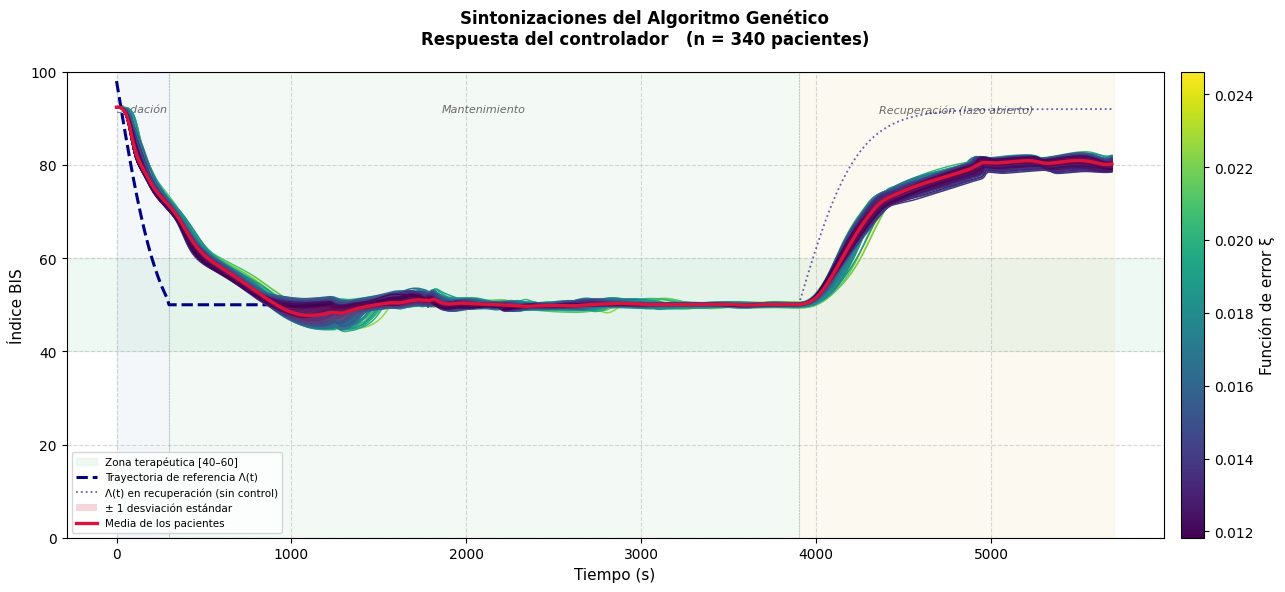

[INFO] Guardada: C:\Users\yordi\Desktop\ag_todas_sintonizaciones_trayectoria.png


In [5]:
# =============================================================================
# FIGURA — SINTONIZACIONES DEL ALGORITMO GENÉTICO
# RESPUESTA DE TODOS LOS PACIENTES SOBRE LA TRAYECTORIA CLÍNICA
# =============================================================================


# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_ag_todos                     # ← Resultado a representar


TITULO_BASE = "Sintonizaciones del Algoritmo Genético"
FIGSIZE     = (13, 6)                    # ← Tamaño de la figura
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "ag_todas_sintonizaciones_trayectoria.png"   # ← Nombre del archivo PNG
COLORMAP    = "viridis"                # ← Mapa de color asociado a ξ 
INVERTIR_COLORMAP = False              # ← Invertir el sentido del mapa de color
LIMITES_COLOR     = None               # ← (mín, máx) de ξ en la barra; None = automático
ETIQUETA_BARRA    = "Función de error ξ"   # ← Rótulo de la barra de color
TAM_BARRA         = 0.035              # ← Anchura relativa de la barra de color
SEPARACION_BARRA  = 0.015              # ← Separación entre el eje y la barra de color

COLOR_REFERENCIA = "navy"        # ← Color de la trayectoria de referencia
ESTILO_REFERENCIA = "--"         # ← Estilo de línea de la referencia
ANCHO_REFERENCIA = 2.2           # ← Grosor de la referencia
ANCHO_PACIENTE   = 1.07           # ← Grosor de las curvas de cada paciente

# Media de las trayectorias de todos los pacientes y franja de dispersión
MOSTRAR_MEDIA  = True            # ← Superponer la media de las trayectorias
COLOR_MEDIA    = "crimson"       # ← Color de la media y de la franja
ANCHO_MEDIA    = 2.4             # ← Grosor de la curva de la media
ESTILO_MEDIA   = "-"             # ← Estilo de línea de la media
ETIQUETA_MEDIA = "Media de los pacientes"   # ← Rótulo de la media en la leyenda
MOSTRAR_BANDA  = True            # ← Mostrar la franja de ± k desviaciones estándar
K_DESVIACIONES = 1.0             # ← Número k de desviaciones estándar de la franja
ALPHA_BANDA    = 0.18            # ← Opacidad de la franja

COLOR_ZONA   = "mediumseagreen"  # ← Color de la zona terapéutica
ALPHA_ZONA   = 0.08              # ← Opacidad de la zona terapéutica
ZONA_INF, ZONA_SUP = 40, 60      # ← Límites de la zona terapéutica

# Colores y opacidad de las bandas que delimitan las tres fases clínicas
COLOR_FASE_SEDACION      = "steelblue"
COLOR_FASE_MANTENIMIENTO = "mediumseagreen"
COLOR_FASE_RECUPERACION  = "goldenrod"
ALPHA_FASES  = 0.06
MOSTRAR_ETIQUETAS_FASE = True    # ← Mostrar los rótulos de cada fase

LIMITES_Y     = (0, 100)         # ← Límites del eje vertical
TAM_TITULO    = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS = 11               # ← Tamaño de fuente de los ejes
TAM_LEYENDA   = 7.5              # ← Tamaño de fuente de la leyenda (referencia y zona terapéutica)
POSICION_LEYENDA = "lower left"  # ← Posición de la leyenda
ALPHA_REJILLA = 0.5             # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

xi_vals = RES["xi"]
bis     = RES["bis"]
df_alg  = RES["df"]

# Se representan todos los pacientes, ordenados de forma ascendente por ξ
n_sel   = len(xi_vals)
idx_sel = np.argsort(xi_vals)

# ── Asignación del color de cada respuesta en función de su valor de ξ ───────
mapa = mpl.colormaps[COLORMAP]
if INVERTIR_COLORMAP:
    mapa = mapa.reversed()
xi_pacientes = xi_vals[idx_sel]
if LIMITES_COLOR is not None:
    v_min, v_max = LIMITES_COLOR
else:
    v_min, v_max = float(xi_pacientes.min()), float(xi_pacientes.max())
if v_max <= v_min:                       # Evita un intervalo de color nulo
    v_max = v_min + 1e-12
norma = mpl.colors.Normalize(vmin=v_min, vmax=v_max)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.suptitle(
    f"{TITULO_BASE}\n"
    f"Respuesta del controlador   (n = {n_sel} pacientes)",
    fontsize=TAM_TITULO, fontweight="bold"
)

# Bandas de las tres fases clínicas
t_s2 = T_SEDACION
t_m2 = T_SEDACION + T_MANTENIMIENTO
t_r2 = N_TOT * DT
ax.axvspan(0,    t_s2, alpha=ALPHA_FASES, color=COLOR_FASE_SEDACION,      zorder=0)
ax.axvspan(t_s2, t_m2, alpha=ALPHA_FASES, color=COLOR_FASE_MANTENIMIENTO, zorder=0)
ax.axvspan(t_m2, t_r2, alpha=ALPHA_FASES, color=COLOR_FASE_RECUPERACION,  zorder=0)
for t_lim in (t_s2, t_m2):
    ax.axvline(t_lim, color="dimgray", lw=0.4, ls="--", alpha=0.5)

if MOSTRAR_ETIQUETAS_FASE:
    y_etiqueta = LIMITES_Y[0] + 0.93 * (LIMITES_Y[1] - LIMITES_Y[0])
    for medio, rotulo in [(t_s2 / 2, "Sedación"),
                          ((t_s2 + t_m2) / 2, "Mantenimiento"),
                          ((t_m2 + t_r2) / 2, "Recuperación (lazo abierto)")]:
        ax.text(medio, y_etiqueta, rotulo, ha="center", va="top",
                fontsize=8, color="dimgray", style="italic")

# Zona terapéutica y trayectoria de referencia
ax.axhspan(ZONA_INF, ZONA_SUP, alpha=ALPHA_ZONA, color=COLOR_ZONA,
           label=f"Zona terapéutica [{ZONA_INF}–{ZONA_SUP}]", zorder=0)
ax.plot(EJE_T[:N_CTRL + 1], LAMBDA_REF[:N_CTRL + 1], color=COLOR_REFERENCIA,
        lw=ANCHO_REFERENCIA, ls=ESTILO_REFERENCIA,
        label="Trayectoria de referencia Λ(t)", zorder=3)
# En la recuperación el controlador permanece desactivado; Λ(t) se muestra
# únicamente como curva de comparación
ax.plot(EJE_T[N_CTRL:], LAMBDA_REF[N_CTRL:], color=COLOR_REFERENCIA,
        lw=0.6 * ANCHO_REFERENCIA, ls=":", alpha=0.6,
        label="Λ(t) en recuperación (sin control)", zorder=3)

# Curvas de todos los pacientes, coloreadas según su valor de ξ. Se
# trazan en orden descendente de ξ, de modo que las respuestas de menor error
# queden superpuestas sobre las restantes.
for idx in idx_sel[::-1]:
    ax.plot(EJE_T, bis[idx], color=mapa(norma(xi_vals[idx])),
            lw=ANCHO_PACIENTE, zorder=4)

# Media de las trayectorias de todos los pacientes y franja de ± k desviaciones
# estándar. La desviación estándar se calcula con corrección de Bessel
# (ddof = 1), por tratarse de una estimación a partir de una muestra.
if MOSTRAR_MEDIA:
    bis_pacientes = bis[idx_sel]
    media_bis   = bis_pacientes.mean(axis=0)
    if MOSTRAR_BANDA and n_sel > 1:
        desv_bis = K_DESVIACIONES * bis_pacientes.std(axis=0, ddof=1)
        ax.fill_between(EJE_T, media_bis - desv_bis, media_bis + desv_bis,
                        color=COLOR_MEDIA, alpha=ALPHA_BANDA, lw=0, zorder=5,
                        label=f"± {K_DESVIACIONES:g} desviación estándar")
    ax.plot(EJE_T, media_bis, color=COLOR_MEDIA, lw=ANCHO_MEDIA,
            ls=ESTILO_MEDIA, label=ETIQUETA_MEDIA, zorder=6)

ax.set_xlabel("Tiempo (s)", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("Índice BIS", fontsize=TAM_ETIQUETAS)
ax.set_ylim(*LIMITES_Y)
ax.legend(fontsize=TAM_LEYENDA, loc=POSICION_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# Barra de color que relaciona cada tono con el valor de ξ del paciente
barra = fig.colorbar(mpl.cm.ScalarMappable(norm=norma, cmap=mapa), ax=ax,
                     fraction=TAM_BARRA, pad=SEPARACION_BARRA)
barra.set_label(ETIQUETA_BARRA, fontsize=TAM_ETIQUETAS)

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


## Etapa 4: Algoritmo de K vecinos más cercanos

In [6]:
# =============================================================================
# ALGORITMO DE K VECINOS MÁS CERCANOS — FUNCIONES BASE
# =============================================================================
#
# Procedimiento de estimación de los hiperparámetros del PID proporcional:
#
#   1. Los vectores de características del Espacio se normalizan mediante
#      min-max al intervalo [0, 1]. La variable Sexo, por ser categórica
#      binaria, se codifica directamente como 0 y 1 sin reescalamiento.
#
#   2. Cada paciente a estimar se normaliza con esos mismos rangos y se
#      calculan sus distancias de Minkowski respecto a todo el Espacio.
#
#   3. Se seleccionan los K vecinos más cercanos, se toman los inversos de sus
#      distancias (1/dᵢ) y se transforman mediante la función softmax, de modo
#      que los pesos resultantes sumen la unidad.
#
#   4. La estimación es la combinación lineal de los vectores de
#      hiperparámetros de dichos vecinos, ponderada por esos pesos, y se acota
#      finalmente al intervalo admisible.
#
#   5. El desempeño de cada valor del exponente p se evalúa simulando el lazo
#      de control y calculando la función de error ξ.

# Cotas de la estimación final, parámetro a parámetro [Kp, Ki, Kd, γ];
# coinciden con el intervalo de búsqueda del Algoritmo Genético empleado en la
# sintonización poblacional (GANANCIAS_INF/SUP y RHO_INF/SUP)
COTA_INF = np.array([1e-9, 1e-9, 1e-9, 1e-8])   # ← Cotas inferiores
COTA_SUP = np.array([0.5,  0.5,  0.5,  3.0])    # ← Cotas superiores
COLS_HIPER = ["Kp", "Ki", "Kd", "gamma"]   # Hiperparámetros a estimar


def generar_valores_p(p_inicio: float, p_fin: float,
                       p_incremento: float) -> list:
    """
    Genera la lista de exponentes p de la distancia de Minkowski a evaluar,
    a partir del valor inicial, el valor final y el incremento especificados.

    Parámetros
    ----------
    p_inicio     : primer valor del exponente
    p_fin        : último valor del exponente (inclusive)
    p_incremento : paso entre valores consecutivos

    Retorna
    -------
    list de floats con los valores del exponente
    """
    n_pasos = int(round((p_fin - p_inicio) / p_incremento)) + 1
    return [round(p_inicio + i * p_incremento, 10) for i in range(n_pasos)]


def ajustar_normalizador(df_ref: pd.DataFrame, columnas: list) -> dict:
    """
    Calcula los rangos min-max de las variables a partir del Espacio.
    """
    return {c: (float(df_ref[c].min()), float(df_ref[c].max()))
            for c in columnas}


def aplicar_normalizador(df_dat: pd.DataFrame, columnas: list,
                          rangos: dict) -> np.ndarray:
    """
    Construye la matriz de vectores de características normalizados.

    Las variables continuas se reescalan al intervalo [0, 1] con los rangos
    del Espacio. La variable Sexo se emplea directamente con sus valores 0 y 1.
    Si el rango de alguna variable resulta nulo, dicha variable se fija en cero
    para evitar una división entre cero.
    """
    X = np.zeros((len(df_dat), len(columnas)), dtype=np.float64)
    for j, c in enumerate(columnas):
        valores = df_dat[c].to_numpy(dtype=np.float64)
        if c == "Sexo_num":
            X[:, j] = valores          # Categórica binaria: sin reescalamiento
        else:
            v_min, v_max = rangos[c]
            X[:, j] = 0.0 if v_max == v_min else (valores - v_min) / (v_max - v_min)
    return X


def distancia_minkowski(X_ref: np.ndarray, x_consulta: np.ndarray,
                         p: float) -> np.ndarray:
    """
    Distancia de Minkowski de orden p:  d(x,y) = ( Σ |xᵢ − yᵢ|^p )^(1/p)
    """
    return np.sum(np.abs(X_ref - x_consulta[None, :]) ** p, axis=1) ** (1.0 / p)


def pesos_softmax_inversos(distancias: np.ndarray) -> np.ndarray:
    """
    Calcula los pesos de la combinación lineal a partir de los inversos de las
    distancias de los K vecinos, transformados mediante la función softmax:

        wᵢ = exp(1/dᵢ) / Σⱼ exp(1/dⱼ)

    Se sustrae el máximo antes de exponenciar, procedimiento numéricamente
    estable que evita desbordamientos cuando alguna distancia es muy próxima
    a cero.
    """
    inversos   = 1.0 / np.maximum(distancias, 1e-12)
    exponentes = np.exp(inversos - np.max(inversos))
    return exponentes / np.sum(exponentes)


def estimar_hiperparametros_knn(X_espacio: np.ndarray, Y_espacio: np.ndarray,
                                 X_consulta: np.ndarray, k: int, p: float,
                                 cota_inf: np.ndarray = COTA_INF,
                                 cota_sup: np.ndarray = COTA_SUP) -> np.ndarray:
    """
    Estima los hiperparámetros del controlador mediante K vecinos más cercanos
    con ponderación softmax de los inversos de las distancias de Minkowski.

    Parámetros
    ----------
    X_espacio  : (M, D) — vectores normalizados del Espacio
    Y_espacio  : (M, H) — hiperparámetros asociados a cada elemento del Espacio
    X_consulta : (N, D) — vectores normalizados de los pacientes a estimar
    k          : número de vecinos
    p          : orden de la distancia de Minkowski

    Retorna
    -------
    (N, H) — hiperparámetros estimados, acotados al intervalo admisible
    """
    N, H = X_consulta.shape[0], Y_espacio.shape[1]
    Y_est = np.zeros((N, H), dtype=np.float64)
    k_efectivo = min(k, X_espacio.shape[0])

    for i in range(N):
        d = distancia_minkowski(X_espacio, X_consulta[i], p)
        idx_vecinos = np.argsort(d)[:k_efectivo]
        w = pesos_softmax_inversos(d[idx_vecinos])
        Y_est[i] = w @ Y_espacio[idx_vecinos]

    return np.clip(Y_est, cota_inf, cota_sup)


def barrido_exponente_p(X_espacio, Y_espacio, X_consulta, Y_real,
                         df_consulta, k, valores_p, mostrar_progreso=True):
    """
    Ejecuta la estimación para cada valor del exponente p, simula el lazo de
    control resultante y evalúa la función de error ξ.

    Adicionalmente se registra, con carácter informativo, el error absoluto
    medio de cada hiperparámetro respecto a los valores obtenidos previamente
    mediante Algoritmo Genético.

    Retorna
    -------
    tabla     : DataFrame con una fila por valor de p
    registros : dict {p: (Y_est, xi, bis)} con los resultados detallados
    """
    filas, registros = [], {}
    t0 = time.time()

    for n_p, p in enumerate(valores_p, start=1):
        Y_est = estimar_hiperparametros_knn(X_espacio, Y_espacio,
                                             X_consulta, k, p)
        xi, bis = evaluar_cohorte(Y_est, df_consulta)

        fila = {"p": p,
                "xi medio": float(np.mean(xi)),
                "xi desv.est.": float(np.std(xi, ddof=1)) if len(xi) > 1 else np.nan,
                "xi mínimo": float(np.min(xi))}
        # Error absoluto medio por hiperparámetro (informativo)
        for j, c in enumerate(COLS_HIPER):
            fila[f"EAM {c}"] = float(np.mean(np.abs(Y_est[:, j] - Y_real[:, j])))

        filas.append(fila)
        registros[p] = (Y_est, xi, bis)

        if mostrar_progreso:
            transcurrido = time.time() - t0
            eta = transcurrido * (len(valores_p) - n_p) / n_p
            sys.stdout.write(
                f"\r    p = {p:<6.3f}  ({n_p:>3d}/{len(valores_p)})  "
                f"ξ medio = {fila['xi medio']:.6f}   "
                f"[{transcurrido:5.0f}s, ETA {eta:5.0f}s]        ")
            sys.stdout.flush()

    if mostrar_progreso:
        sys.stdout.write("\n")

    return pd.DataFrame(filas), registros


def ejecutar_algoritmo_knn(df_espacio_alg, df_estimados_alg, columnas_vector,
                            k, valores_p, nombre_algoritmo) -> dict:
    """
    Ejecuta el procedimiento completo de un algoritmo: normalización, barrido
    sobre el exponente p, selección del valor con menor ξ medio y presentación
    de los resultados.

    Parámetros
    ----------
    df_espacio_alg   : DataFrame del Espacio del algoritmo
    df_estimados_alg : DataFrame de los pacientes a estimar
    columnas_vector  : variables que conforman el vector de características
    k                : número de vecinos del algoritmo
    valores_p        : lista de exponentes de Minkowski a evaluar
    nombre_algoritmo : denominación del algoritmo

    Retorna
    -------
    dict con: nombre, tabla_p, mejor_p, k, Y_est, xi, bis, df
    """
    print("\n" + "=" * 78)
    print(f"  {nombre_algoritmo}")
    print(f"  Vector de características : {columnas_vector}")
    print(f"  Espacio: {len(df_espacio_alg)} pacientes   |   "
          f"A estimar: {len(df_estimados_alg)} pacientes   |   K = {k}")
    print(f"  Exponentes p evaluados    : {len(valores_p)}  "
          f"(de {valores_p[0]} a {valores_p[-1]})")
    print("=" * 78)

    if len(df_espacio_alg) < k:
        raise ValueError(f"El Espacio ({len(df_espacio_alg)}) es menor que K = {k}.")
    if len(df_estimados_alg) == 0:
        raise ValueError("No hay pacientes que estimar en este algoritmo.")

    rangos = ajustar_normalizador(df_espacio_alg, columnas_vector)
    X_esp  = aplicar_normalizador(df_espacio_alg,  columnas_vector, rangos)
    X_est  = aplicar_normalizador(df_estimados_alg, columnas_vector, rangos)
    Y_esp  = df_espacio_alg[COLS_HIPER].to_numpy(dtype=np.float64)
    Y_real = df_estimados_alg[COLS_HIPER].to_numpy(dtype=np.float64)

    print("\n  Barrido sobre el exponente de la distancia de Minkowski:")
    tabla_p, registros = barrido_exponente_p(
        X_esp, Y_esp, X_est, Y_real, df_estimados_alg, k, valores_p
    )

    print("\n  RESULTADOS POR VALOR DE p")
    print("  " + "─" * 74)
    try:
        display(tabla_p)
    except NameError:
        print(tabla_p.to_string(index=False))

    idx_mejor = int(tabla_p["xi medio"].idxmin())
    mejor_p   = float(tabla_p.loc[idx_mejor, "p"])
    Y_est, xi, bis = registros[mejor_p]

    print(f"\n  ► Mejor exponente: p = {mejor_p}   "
          f"(ξ medio = {tabla_p.loc[idx_mejor, 'xi medio']:.6f})")
    print("  " + "─" * 74)
    print(f"  {'ξ medio':<24}: {np.mean(xi):.6f}")
    print(f"  {'ξ desviación estándar':<24}: "
          f"{np.std(xi, ddof=1) if len(xi) > 1 else float('nan'):.6f}")
    print(f"  {'ξ mínimo / máximo':<24}: {np.min(xi):.6f} / {np.max(xi):.6f}")
    print("=" * 78)

    return {"nombre": nombre_algoritmo, "tabla_p": tabla_p, "mejor_p": mejor_p,
            "k": k, "Y_est": Y_est, "xi": xi, "bis": bis,
            "df": df_estimados_alg.reset_index(drop=True)}


## Etapa 5: Algoritmo 1 — Estimación global

In [7]:
# =============================================================================
# ALGORITMO 1 — ESTIMACIÓN GLOBAL 
# =============================================================================
#
# El vector de características se conforma con las cuatro variables
# disponibles. El Espacio empleado es el conjunto global, equilibrado al 50 %
# entre hombres y mujeres.

# ── Parámetros ajustables de este algoritmo ──────────────────────────────────
K_ALG1 = 2        # ← Número de vecinos más cercanos para este algoritmo

P_INICIO_ALG1     = 1.0    # ← Valor inicial del exponente de Minkowski
P_FIN_ALG1        = 3.0    # ← Valor final   del exponente de Minkowski
P_INCREMENTO_ALG1 = 0.1    # ← Incremento entre valores consecutivos

COLUMNAS_ALG1 = ["Edad", "Peso", "Altura", "Sexo_num"]

VALORES_P_ALG1 = generar_valores_p(P_INICIO_ALG1, P_FIN_ALG1, P_INCREMENTO_ALG1)

resultado_global = ejecutar_algoritmo_knn(
    df_espacio, df_estimados,
    COLUMNAS_ALG1, K_ALG1, VALORES_P_ALG1,
    "ALGORITMO 1 — Estimación global (edad, peso, altura, sexo)"
)



  ALGORITMO 1 — Estimación global (edad, peso, altura, sexo)
  Vector de características : ['Edad', 'Peso', 'Altura', 'Sexo_num']
  Espacio: 134 pacientes   |   A estimar: 200 pacientes   |   K = 2
  Exponentes p evaluados    : 21  (de 1.0 a 3.0)

  Barrido sobre el exponente de la distancia de Minkowski:
    p = 3.000   ( 21/21)  ξ medio = 0.016339   [   92s, ETA     0s]        

  RESULTADOS POR VALOR DE p
  ──────────────────────────────────────────────────────────────────────────


,p,xi medio,xi desv.est.,xi mínimo,EAM Kp,EAM Ki,EAM Kd,EAM gamma
0,1.0,0.016219,0.002912,0.011706,0.002634,1.723582e-07,0.100913,0.596138
1,1.1,0.016237,0.002874,0.011688,0.002638,1.734031e-07,0.100971,0.604143
2,1.2,0.016311,0.003094,0.011668,0.002660,1.740604e-07,0.101027,0.603799
3,1.3,0.016334,0.003050,0.011672,0.002666,1.747666e-07,0.100649,0.604298
4,1.4,0.016332,0.003045,0.011670,0.002667,1.752972e-07,0.100000,0.602122
5,1.5,0.016369,0.003103,0.011666,0.002670,1.762974e-07,0.100477,0.600481
6,1.6,0.016390,0.003099,0.011680,0.002669,1.771223e-07,0.100562,0.603022
7,1.7,0.016361,0.002987,0.011688,0.002664,1.767812e-07,0.100091,0.596143
8,1.8,0.016365,0.002989,0.011708,0.002667,1.767781e-07,0.099693,0.603025
9,1.9,0.016362,0.002992,0.011717,0.002665,1.768291e-07,0.099786,0.606229



  ► Mejor exponente: p = 1.0   (ξ medio = 0.016219)
  ──────────────────────────────────────────────────────────────────────────
  ξ medio                 : 0.016219
  ξ desviación estándar   : 0.002912
  ξ mínimo / máximo       : 0.011706 / 0.035031


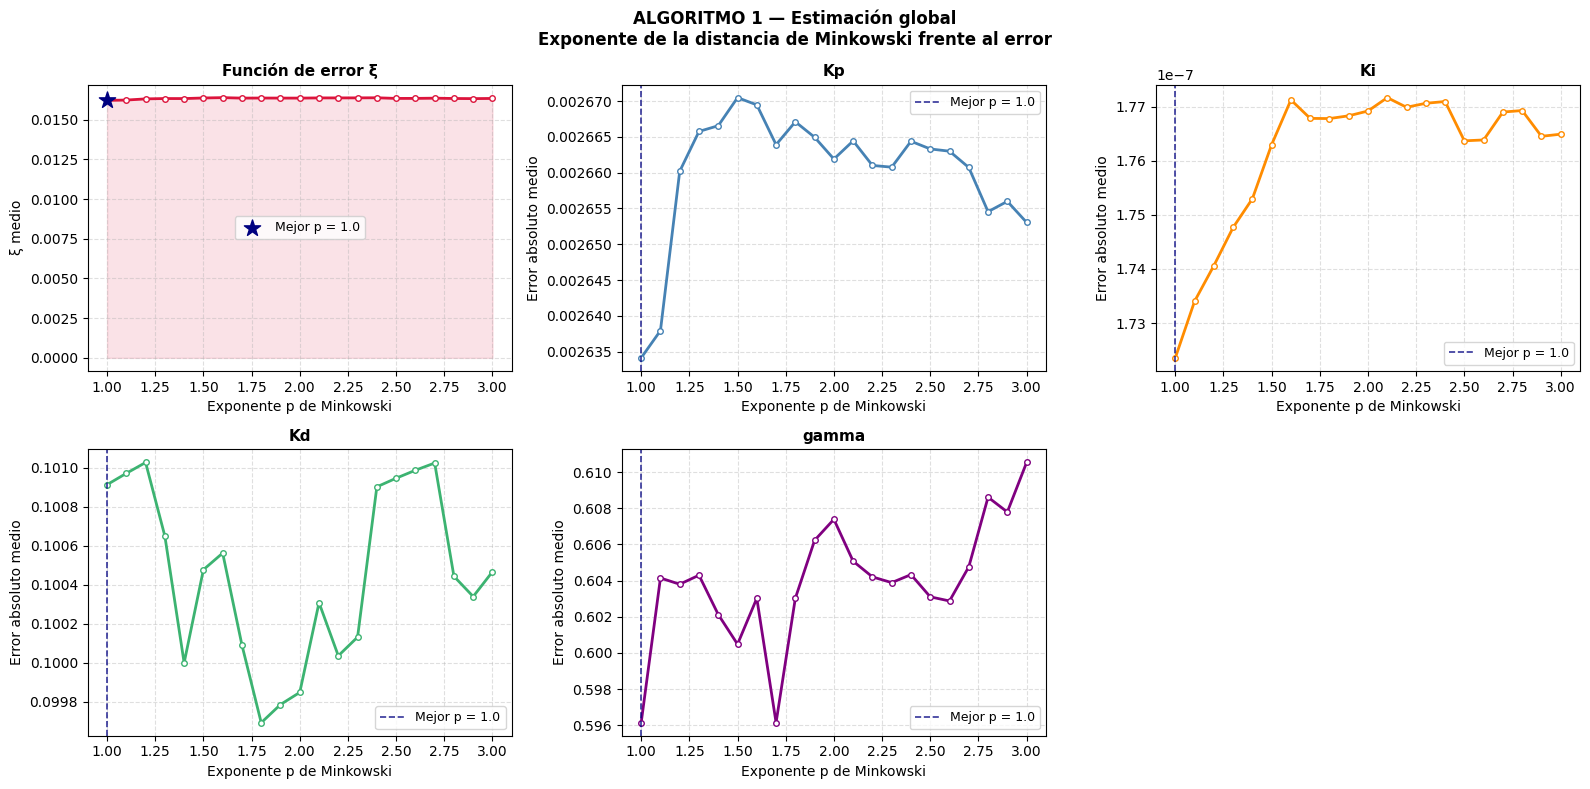

[INFO] Guardada: C:\Users\yordi\Desktop\knn_alg1_barrido_p.png


In [8]:
# =============================================================================
# FIGURA — ALGORITMO 1 — Estimación global
# EXPONENTE DE MINKOWSKI FRENTE AL ERROR
# =============================================================================

# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_global                       # ← Resultado del algoritmo a representar

TITULO      = ("ALGORITMO 1 — Estimación global\n"
               "Exponente de la distancia de Minkowski frente al error")
FIGSIZE     = (16, 8)                    # ← Tamaño de la figura (ancho, alto)
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "knn_alg1_barrido_p.png"    # ← Nombre del archivo PNG

COLOR_XI       = "crimson"        # ← Color de la curva de ξ
COLOR_MEJOR    = "navy"           # ← Color del marcador del mejor exponente
COLORES_HIPER  = ["steelblue", "darkorange",
                  "mediumseagreen", "purple"]   # ← Un color por hiperparámetro

ANCHO_LINEA    = 2.0              # ← Grosor de las curvas
TAM_MARCADOR   = 4                # ← Tamaño de los marcadores
ALPHA_RELLENO  = 0.12             # ← Opacidad del relleno bajo la curva de ξ
TAM_TITULO     = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS  = 10               # ← Tamaño de fuente de los ejes
TAM_LEYENDA    = 9                # ← Tamaño de fuente de la leyenda
ALPHA_REJILLA  = 0.4              # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

tabla    = RES["tabla_p"]
p_vals   = tabla["p"].to_numpy()
mejor_p  = RES["mejor_p"]
idx_best = int(np.argmin(np.abs(p_vals - mejor_p)))

fig, ejes = plt.subplots(2, 3, figsize=FIGSIZE)
fig.suptitle(TITULO, fontsize=TAM_TITULO, fontweight="bold")
ejes_planos = ejes.flatten()

# ── Panel principal: función de error ξ ──────────────────────────────────────
ax = ejes_planos[0]
xi_vals = tabla["xi medio"].to_numpy()
ax.plot(p_vals, xi_vals, color=COLOR_XI, lw=ANCHO_LINEA,
        marker="o", ms=TAM_MARCADOR, markerfacecolor="white")
ax.fill_between(p_vals, xi_vals, alpha=ALPHA_RELLENO, color=COLOR_XI)
ax.scatter([mejor_p], [xi_vals[idx_best]], s=150, marker="*",
           color=COLOR_MEJOR, zorder=5,
           label=f"Mejor p = {mejor_p}")
ax.set_xlabel("Exponente p de Minkowski", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("ξ medio", fontsize=TAM_ETIQUETAS)
ax.set_title("Función de error ξ", fontsize=TAM_ETIQUETAS + 1, fontweight="bold")
ax.legend(fontsize=TAM_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# ── Paneles por hiperparámetro: error absoluto medio ─────────────────────────
for j, nombre_h in enumerate(COLS_HIPER):
    ax = ejes_planos[j + 1]
    valores = tabla[f"EAM {nombre_h}"].to_numpy()
    ax.plot(p_vals, valores, color=COLORES_HIPER[j % len(COLORES_HIPER)],
            lw=ANCHO_LINEA, marker="o", ms=TAM_MARCADOR,
            markerfacecolor="white")
    ax.axvline(mejor_p, color=COLOR_MEJOR, ls="--", lw=1.2, alpha=0.8,
               label=f"Mejor p = {mejor_p}")
    ax.set_xlabel("Exponente p de Minkowski", fontsize=TAM_ETIQUETAS)
    ax.set_ylabel(f"Error absoluto medio", fontsize=TAM_ETIQUETAS)
    ax.set_title(nombre_h, fontsize=TAM_ETIQUETAS + 1, fontweight="bold")
    ax.legend(fontsize=TAM_LEYENDA)
    ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

ejes_planos[5].set_visible(False)   # Panel sobrante

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


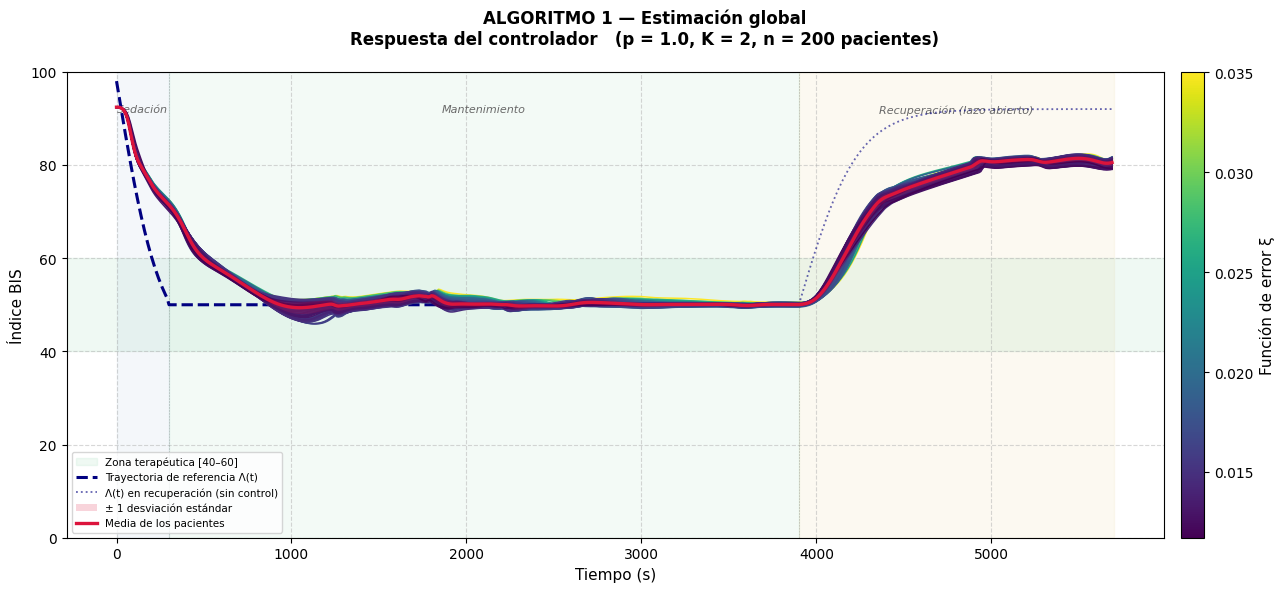

[INFO] Guardada: C:\Users\yordi\Desktop\knn_alg1_trayectoria.png


In [9]:
# =============================================================================
# FIGURA — ALGORITMO 1 — Estimación global
# RESPUESTA DEL CONTROLADOR SOBRE LA TRAYECTORIA CLÍNICA
# =============================================================================


# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_global                       # ← Resultado del algoritmo a representar


TITULO_BASE = "ALGORITMO 1 — Estimación global"
FIGSIZE     = (13, 6)                    # ← Tamaño de la figura
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "knn_alg1_trayectoria.png"   # ← Nombre del archivo PNG
COLORMAP    = "viridis"                # ← Mapa de color asociado a ξ 
INVERTIR_COLORMAP = False              # ← Invertir el sentido del mapa de color
LIMITES_COLOR     = None               # ← (mín, máx) de ξ en la barra; None = automático
ETIQUETA_BARRA    = "Función de error ξ"   # ← Rótulo de la barra de color
TAM_BARRA         = 0.035              # ← Anchura relativa de la barra de color
SEPARACION_BARRA  = 0.015              # ← Separación entre el eje y la barra de color

COLOR_REFERENCIA = "navy"        # ← Color de la trayectoria de referencia
ESTILO_REFERENCIA = "--"         # ← Estilo de línea de la referencia
ANCHO_REFERENCIA = 2.2           # ← Grosor de la referencia
ANCHO_PACIENTE   = 1.07           # ← Grosor de las curvas de cada paciente

# Media de las trayectorias de todos los pacientes y franja de dispersión
MOSTRAR_MEDIA  = True            # ← Superponer la media de las trayectorias
COLOR_MEDIA    = "crimson"       # ← Color de la media y de la franja
ANCHO_MEDIA    = 2.4             # ← Grosor de la curva de la media
ESTILO_MEDIA   = "-"             # ← Estilo de línea de la media
ETIQUETA_MEDIA = "Media de los pacientes"   # ← Rótulo de la media en la leyenda
MOSTRAR_BANDA  = True            # ← Mostrar la franja de ± k desviaciones estándar
K_DESVIACIONES = 1.0             # ← Número k de desviaciones estándar de la franja
ALPHA_BANDA    = 0.18            # ← Opacidad de la franja

COLOR_ZONA   = "mediumseagreen"  # ← Color de la zona terapéutica
ALPHA_ZONA   = 0.08              # ← Opacidad de la zona terapéutica
ZONA_INF, ZONA_SUP = 40, 60      # ← Límites de la zona terapéutica

# Colores y opacidad de las bandas que delimitan las tres fases clínicas
COLOR_FASE_SEDACION      = "steelblue"
COLOR_FASE_MANTENIMIENTO = "mediumseagreen"
COLOR_FASE_RECUPERACION  = "goldenrod"
ALPHA_FASES  = 0.06
MOSTRAR_ETIQUETAS_FASE = True    # ← Mostrar los rótulos de cada fase

LIMITES_Y     = (0, 100)         # ← Límites del eje vertical
TAM_TITULO    = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS = 11               # ← Tamaño de fuente de los ejes
TAM_LEYENDA   = 7.5              # ← Tamaño de fuente de la leyenda (referencia y zona terapéutica)
POSICION_LEYENDA = "lower left"  # ← Posición de la leyenda
ALPHA_REJILLA = 0.5             # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

xi_vals = RES["xi"]
bis     = RES["bis"]
df_alg  = RES["df"]

# Se representan todos los pacientes, ordenados de forma ascendente por ξ
n_sel   = len(xi_vals)
idx_sel = np.argsort(xi_vals)

# ── Asignación del color de cada respuesta en función de su valor de ξ ───────
mapa = mpl.colormaps[COLORMAP]
if INVERTIR_COLORMAP:
    mapa = mapa.reversed()
xi_pacientes = xi_vals[idx_sel]
if LIMITES_COLOR is not None:
    v_min, v_max = LIMITES_COLOR
else:
    v_min, v_max = float(xi_pacientes.min()), float(xi_pacientes.max())
if v_max <= v_min:                       # Evita un intervalo de color nulo
    v_max = v_min + 1e-12
norma = mpl.colors.Normalize(vmin=v_min, vmax=v_max)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.suptitle(
    f"{TITULO_BASE}\n"
    f"Respuesta del controlador   "
    f"(p = {RES['mejor_p']}, K = {RES['k']}, n = {n_sel} pacientes)",
    fontsize=TAM_TITULO, fontweight="bold"
)

# Bandas de las tres fases clínicas
t_s2 = T_SEDACION
t_m2 = T_SEDACION + T_MANTENIMIENTO
t_r2 = N_TOT * DT
ax.axvspan(0,    t_s2, alpha=ALPHA_FASES, color=COLOR_FASE_SEDACION,      zorder=0)
ax.axvspan(t_s2, t_m2, alpha=ALPHA_FASES, color=COLOR_FASE_MANTENIMIENTO, zorder=0)
ax.axvspan(t_m2, t_r2, alpha=ALPHA_FASES, color=COLOR_FASE_RECUPERACION,  zorder=0)
for t_lim in (t_s2, t_m2):
    ax.axvline(t_lim, color="dimgray", lw=0.4, ls="--", alpha=0.5)

if MOSTRAR_ETIQUETAS_FASE:
    y_etiqueta = LIMITES_Y[0] + 0.93 * (LIMITES_Y[1] - LIMITES_Y[0])
    for medio, rotulo in [(t_s2 / 2, "Sedación"),
                          ((t_s2 + t_m2) / 2, "Mantenimiento"),
                          ((t_m2 + t_r2) / 2, "Recuperación (lazo abierto)")]:
        ax.text(medio, y_etiqueta, rotulo, ha="center", va="top",
                fontsize=8, color="dimgray", style="italic")

# Zona terapéutica y trayectoria de referencia
ax.axhspan(ZONA_INF, ZONA_SUP, alpha=ALPHA_ZONA, color=COLOR_ZONA,
           label=f"Zona terapéutica [{ZONA_INF}–{ZONA_SUP}]", zorder=0)
ax.plot(EJE_T[:N_CTRL + 1], LAMBDA_REF[:N_CTRL + 1], color=COLOR_REFERENCIA,
        lw=ANCHO_REFERENCIA, ls=ESTILO_REFERENCIA,
        label="Trayectoria de referencia Λ(t)", zorder=3)
# En la recuperación el controlador permanece desactivado; Λ(t) se muestra
# únicamente como curva de comparación
ax.plot(EJE_T[N_CTRL:], LAMBDA_REF[N_CTRL:], color=COLOR_REFERENCIA,
        lw=0.6 * ANCHO_REFERENCIA, ls=":", alpha=0.6,
        label="Λ(t) en recuperación (sin control)", zorder=3)

# Curvas de todos los pacientes, coloreadas según su valor de ξ. Se
# trazan en orden descendente de ξ, de modo que las respuestas de menor error
# queden superpuestas sobre las restantes.
for idx in idx_sel[::-1]:
    ax.plot(EJE_T, bis[idx], color=mapa(norma(xi_vals[idx])),
            lw=ANCHO_PACIENTE, zorder=4)

# Media de las trayectorias de todos los pacientes y franja de ± k desviaciones
# estándar. La desviación estándar se calcula con corrección de Bessel
# (ddof = 1), por tratarse de una estimación a partir de una muestra.
if MOSTRAR_MEDIA:
    bis_pacientes = bis[idx_sel]
    media_bis   = bis_pacientes.mean(axis=0)
    if MOSTRAR_BANDA and n_sel > 1:
        desv_bis = K_DESVIACIONES * bis_pacientes.std(axis=0, ddof=1)
        ax.fill_between(EJE_T, media_bis - desv_bis, media_bis + desv_bis,
                        color=COLOR_MEDIA, alpha=ALPHA_BANDA, lw=0, zorder=5,
                        label=f"± {K_DESVIACIONES:g} desviación estándar")
    ax.plot(EJE_T, media_bis, color=COLOR_MEDIA, lw=ANCHO_MEDIA,
            ls=ESTILO_MEDIA, label=ETIQUETA_MEDIA, zorder=6)

ax.set_xlabel("Tiempo (s)", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("Índice BIS", fontsize=TAM_ETIQUETAS)
ax.set_ylim(*LIMITES_Y)
ax.legend(fontsize=TAM_LEYENDA, loc=POSICION_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# Barra de color que relaciona cada tono con el valor de ξ del paciente
barra = fig.colorbar(mpl.cm.ScalarMappable(norm=norma, cmap=mapa), ax=ax,
                     fraction=TAM_BARRA, pad=SEPARACION_BARRA)
barra.set_label(ETIQUETA_BARRA, fontsize=TAM_ETIQUETAS)

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


## Etapa 6: Algoritmo 2 — Estimación en pacientes masculinos

In [10]:
# =============================================================================
# ALGORITMO 2 — ESTIMACIÓN RESTRINGIDA A PACIENTES DE SEXO MASCULINO
# =============================================================================
#
# El Espacio se compone de los hombres con menor error. Dado que en este
# subconjunto la variable sexo es constante, el vector de características se
# reduce a las tres variables continuas.

# ── Parámetros ajustables de este algoritmo ──────────────────────────────────
K_ALG2 = 2        # ← Número de vecinos más cercanos para este algoritmo

P_INICIO_ALG2     = 1.0    # ← Valor inicial del exponente de Minkowski
P_FIN_ALG2        = 3.0    # ← Valor final   del exponente de Minkowski
P_INCREMENTO_ALG2 = 0.1    # ← Incremento entre valores consecutivos

COLUMNAS_ALG2 = ["Edad", "Peso", "Altura"]

VALORES_P_ALG2 = generar_valores_p(P_INICIO_ALG2, P_FIN_ALG2, P_INCREMENTO_ALG2)

resultado_hombres = ejecutar_algoritmo_knn(
    df_espacio_h, df_estimados_h,
    COLUMNAS_ALG2, K_ALG2, VALORES_P_ALG2,
    "ALGORITMO 2 — Estimación en pacientes masculinos (edad, peso, altura)"
)



  ALGORITMO 2 — Estimación en pacientes masculinos (edad, peso, altura)
  Vector de características : ['Edad', 'Peso', 'Altura']
  Espacio: 67 pacientes   |   A estimar: 100 pacientes   |   K = 2
  Exponentes p evaluados    : 21  (de 1.0 a 3.0)

  Barrido sobre el exponente de la distancia de Minkowski:
    p = 3.000   ( 21/21)  ξ medio = 0.016709   [   43s, ETA     0s]        

  RESULTADOS POR VALOR DE p
  ──────────────────────────────────────────────────────────────────────────


,p,xi medio,xi desv.est.,xi mínimo,EAM Kp,EAM Ki,EAM Kd,EAM gamma
0,1.0,0.016695,0.003344,0.012532,0.002455,1.769970e-07,0.100861,0.613709
1,1.1,0.016716,0.003347,0.012420,0.002458,1.763560e-07,0.100376,0.604423
2,1.2,0.016680,0.003366,0.012334,0.002460,1.764172e-07,0.099974,0.598666
3,1.3,0.016693,0.003367,0.012274,0.002460,1.768869e-07,0.099809,0.596825
4,1.4,0.016699,0.003353,0.012227,0.002462,1.770196e-07,0.099661,0.599796
5,1.5,0.016680,0.003289,0.012192,0.002460,1.775612e-07,0.099548,0.592304
6,1.6,0.016697,0.003284,0.012171,0.002454,1.782541e-07,0.099459,0.595130
7,1.7,0.016708,0.003274,0.012155,0.002456,1.783492e-07,0.099386,0.599762
8,1.8,0.016736,0.003268,0.012142,0.002453,1.792016e-07,0.099396,0.600244
9,1.9,0.016745,0.003246,0.012136,0.002452,1.779300e-07,0.099341,0.600752



  ► Mejor exponente: p = 2.2   (ξ medio = 0.016651)
  ──────────────────────────────────────────────────────────────────────────
  ξ medio                 : 0.016651
  ξ desviación estándar   : 0.003046
  ξ mínimo / máximo       : 0.012124 / 0.034549


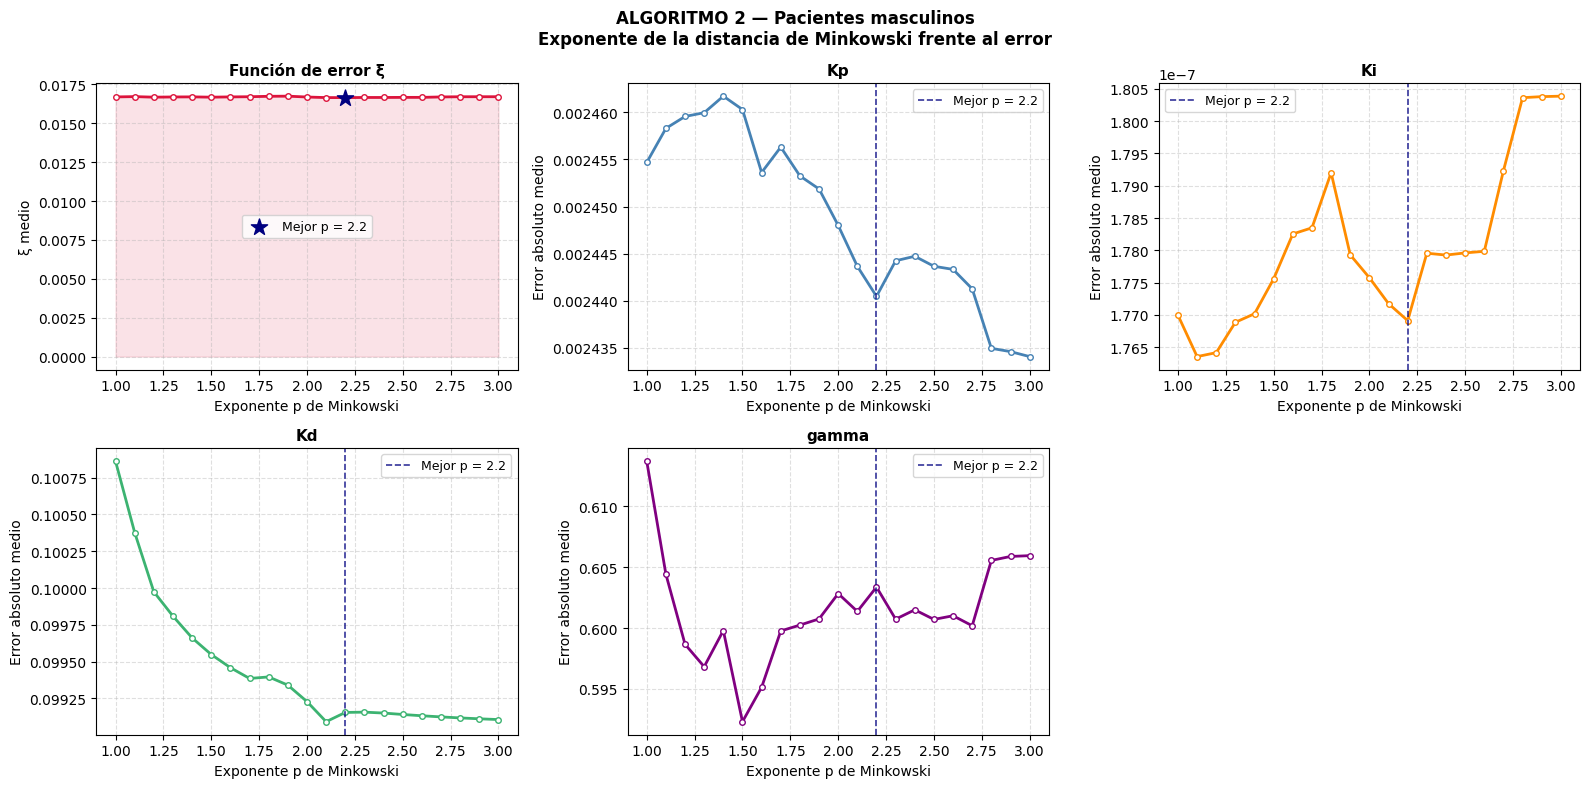

[INFO] Guardada: C:\Users\yordi\Desktop\knn_alg2_barrido_p.png


In [11]:
# =============================================================================
# FIGURA — ALGORITMO 2 — Pacientes masculinos
# EXPONENTE DE MINKOWSKI FRENTE AL ERROR
# =============================================================================

# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_hombres                       # ← Resultado del algoritmo a representar

TITULO      = ("ALGORITMO 2 — Pacientes masculinos\n"
               "Exponente de la distancia de Minkowski frente al error")
FIGSIZE     = (16, 8)                    # ← Tamaño de la figura (ancho, alto)
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "knn_alg2_barrido_p.png"    # ← Nombre del archivo PNG

COLOR_XI       = "crimson"        # ← Color de la curva de ξ
COLOR_MEJOR    = "navy"           # ← Color del marcador del mejor exponente
COLORES_HIPER  = ["steelblue", "darkorange",
                  "mediumseagreen", "purple"]   # ← Un color por hiperparámetro

ANCHO_LINEA    = 2.0              # ← Grosor de las curvas
TAM_MARCADOR   = 4                # ← Tamaño de los marcadores
ALPHA_RELLENO  = 0.12             # ← Opacidad del relleno bajo la curva de ξ
TAM_TITULO     = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS  = 10               # ← Tamaño de fuente de los ejes
TAM_LEYENDA    = 9                # ← Tamaño de fuente de la leyenda
ALPHA_REJILLA  = 0.4              # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

tabla    = RES["tabla_p"]
p_vals   = tabla["p"].to_numpy()
mejor_p  = RES["mejor_p"]
idx_best = int(np.argmin(np.abs(p_vals - mejor_p)))

fig, ejes = plt.subplots(2, 3, figsize=FIGSIZE)
fig.suptitle(TITULO, fontsize=TAM_TITULO, fontweight="bold")
ejes_planos = ejes.flatten()

# ── Panel principal: función de error ξ ──────────────────────────────────────
ax = ejes_planos[0]
xi_vals = tabla["xi medio"].to_numpy()
ax.plot(p_vals, xi_vals, color=COLOR_XI, lw=ANCHO_LINEA,
        marker="o", ms=TAM_MARCADOR, markerfacecolor="white")
ax.fill_between(p_vals, xi_vals, alpha=ALPHA_RELLENO, color=COLOR_XI)
ax.scatter([mejor_p], [xi_vals[idx_best]], s=150, marker="*",
           color=COLOR_MEJOR, zorder=5,
           label=f"Mejor p = {mejor_p}")
ax.set_xlabel("Exponente p de Minkowski", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("ξ medio", fontsize=TAM_ETIQUETAS)
ax.set_title("Función de error ξ", fontsize=TAM_ETIQUETAS + 1, fontweight="bold")
ax.legend(fontsize=TAM_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# ── Paneles por hiperparámetro: error absoluto medio ─────────────────────────
for j, nombre_h in enumerate(COLS_HIPER):
    ax = ejes_planos[j + 1]
    valores = tabla[f"EAM {nombre_h}"].to_numpy()
    ax.plot(p_vals, valores, color=COLORES_HIPER[j % len(COLORES_HIPER)],
            lw=ANCHO_LINEA, marker="o", ms=TAM_MARCADOR,
            markerfacecolor="white")
    ax.axvline(mejor_p, color=COLOR_MEJOR, ls="--", lw=1.2, alpha=0.8,
               label=f"Mejor p = {mejor_p}")
    ax.set_xlabel("Exponente p de Minkowski", fontsize=TAM_ETIQUETAS)
    ax.set_ylabel(f"Error absoluto medio", fontsize=TAM_ETIQUETAS)
    ax.set_title(nombre_h, fontsize=TAM_ETIQUETAS + 1, fontweight="bold")
    ax.legend(fontsize=TAM_LEYENDA)
    ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

ejes_planos[5].set_visible(False)   # Panel sobrante

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


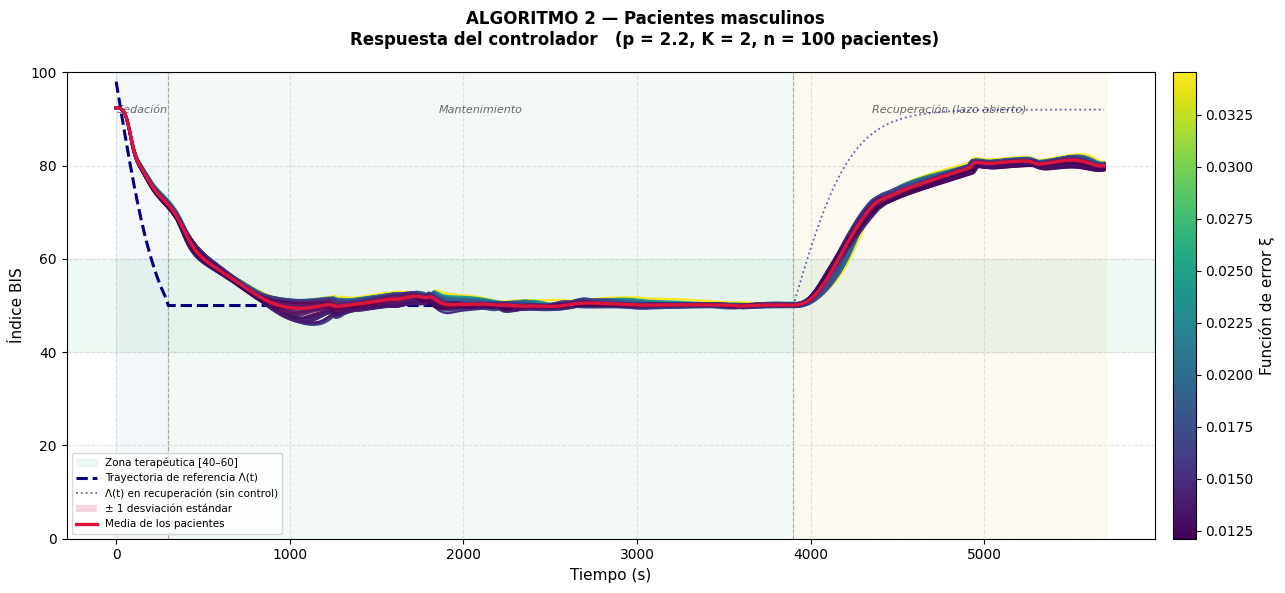

[INFO] Guardada: C:\Users\yordi\Desktop\knn_alg2_trayectoria.png


In [12]:
# =============================================================================
# FIGURA — ALGORITMO 2 — Pacientes masculinos
# RESPUESTA DEL CONTROLADOR SOBRE LA TRAYECTORIA CLÍNICA
# =============================================================================

# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_hombres                       # ← Resultado del algoritmo a representar


TITULO_BASE = "ALGORITMO 2 — Pacientes masculinos"
FIGSIZE     = (13, 6)                    # ← Tamaño de la figura
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "knn_alg2_trayectoria.png"   # ← Nombre del archivo PNG
COLORMAP    = "viridis"                # ← Mapa de color asociado a ξ 
INVERTIR_COLORMAP = False              # ← Invertir el sentido del mapa de color
LIMITES_COLOR     = None               # ← (mín, máx) de ξ en la barra; None = automático
ETIQUETA_BARRA    = "Función de error ξ"   # ← Rótulo de la barra de color
TAM_BARRA         = 0.035              # ← Anchura relativa de la barra de color
SEPARACION_BARRA  = 0.015              # ← Separación entre el eje y la barra de color

COLOR_REFERENCIA = "navy"        # ← Color de la trayectoria de referencia
ESTILO_REFERENCIA = "--"         # ← Estilo de línea de la referencia
ANCHO_REFERENCIA = 2.2           # ← Grosor de la referencia
ANCHO_PACIENTE   = 1.7           # ← Grosor de las curvas de cada paciente

# Media de las trayectorias de todos los pacientes y franja de dispersión
MOSTRAR_MEDIA  = True            # ← Superponer la media de las trayectorias
COLOR_MEDIA    = "crimson"       # ← Color de la media y de la franja
ANCHO_MEDIA    = 2.4             # ← Grosor de la curva de la media
ESTILO_MEDIA   = "-"             # ← Estilo de línea de la media
ETIQUETA_MEDIA = "Media de los pacientes"   # ← Rótulo de la media en la leyenda
MOSTRAR_BANDA  = True            # ← Mostrar la franja de ± k desviaciones estándar
K_DESVIACIONES = 1.0             # ← Número k de desviaciones estándar de la franja
ALPHA_BANDA    = 0.18            # ← Opacidad de la franja

COLOR_ZONA   = "mediumseagreen"  # ← Color de la zona terapéutica
ALPHA_ZONA   = 0.08              # ← Opacidad de la zona terapéutica
ZONA_INF, ZONA_SUP = 40, 60      # ← Límites de la zona terapéutica

# Colores y opacidad de las bandas que delimitan las tres fases clínicas
COLOR_FASE_SEDACION      = "steelblue"
COLOR_FASE_MANTENIMIENTO = "mediumseagreen"
COLOR_FASE_RECUPERACION  = "goldenrod"
ALPHA_FASES  = 0.06
MOSTRAR_ETIQUETAS_FASE = True    # ← Mostrar los rótulos de cada fase

LIMITES_Y     = (0, 100)         # ← Límites del eje vertical
TAM_TITULO    = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS = 11               # ← Tamaño de fuente de los ejes
TAM_LEYENDA   = 7.5              # ← Tamaño de fuente de la leyenda (referencia y zona terapéutica)
POSICION_LEYENDA = "lower left"  # ← Posición de la leyenda
ALPHA_REJILLA = 0.35             # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

xi_vals = RES["xi"]
bis     = RES["bis"]
df_alg  = RES["df"]

# Se representan todos los pacientes, ordenados de forma ascendente por ξ
n_sel   = len(xi_vals)
idx_sel = np.argsort(xi_vals)

# ── Asignación del color de cada respuesta en función de su valor de ξ ───────
mapa = mpl.colormaps[COLORMAP]
if INVERTIR_COLORMAP:
    mapa = mapa.reversed()
xi_pacientes = xi_vals[idx_sel]
if LIMITES_COLOR is not None:
    v_min, v_max = LIMITES_COLOR
else:
    v_min, v_max = float(xi_pacientes.min()), float(xi_pacientes.max())
if v_max <= v_min:                       # Evita un intervalo de color nulo
    v_max = v_min + 1e-12
norma = mpl.colors.Normalize(vmin=v_min, vmax=v_max)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.suptitle(
    f"{TITULO_BASE}\n"
    f"Respuesta del controlador   "
    f"(p = {RES['mejor_p']}, K = {RES['k']}, n = {n_sel} pacientes)",
    fontsize=TAM_TITULO, fontweight="bold"
)

# Bandas de las tres fases clínicas
t_s2 = T_SEDACION
t_m2 = T_SEDACION + T_MANTENIMIENTO
t_r2 = N_TOT * DT
ax.axvspan(0,    t_s2, alpha=ALPHA_FASES, color=COLOR_FASE_SEDACION,      zorder=0)
ax.axvspan(t_s2, t_m2, alpha=ALPHA_FASES, color=COLOR_FASE_MANTENIMIENTO, zorder=0)
ax.axvspan(t_m2, t_r2, alpha=ALPHA_FASES, color=COLOR_FASE_RECUPERACION,  zorder=0)
for t_lim in (t_s2, t_m2):
    ax.axvline(t_lim, color="dimgray", lw=0.8, ls="--", alpha=0.5)

if MOSTRAR_ETIQUETAS_FASE:
    y_etiqueta = LIMITES_Y[0] + 0.93 * (LIMITES_Y[1] - LIMITES_Y[0])
    for medio, rotulo in [(t_s2 / 2, "Sedación"),
                          ((t_s2 + t_m2) / 2, "Mantenimiento"),
                          ((t_m2 + t_r2) / 2, "Recuperación (lazo abierto)")]:
        ax.text(medio, y_etiqueta, rotulo, ha="center", va="top",
                fontsize=8, color="dimgray", style="italic")

# Zona terapéutica y trayectoria de referencia
ax.axhspan(ZONA_INF, ZONA_SUP, alpha=ALPHA_ZONA, color=COLOR_ZONA,
           label=f"Zona terapéutica [{ZONA_INF}–{ZONA_SUP}]", zorder=0)
ax.plot(EJE_T[:N_CTRL + 1], LAMBDA_REF[:N_CTRL + 1], color=COLOR_REFERENCIA,
        lw=ANCHO_REFERENCIA, ls=ESTILO_REFERENCIA,
        label="Trayectoria de referencia Λ(t)", zorder=3)
# En la recuperación el controlador permanece desactivado; Λ(t) se muestra
# únicamente como curva de comparación
ax.plot(EJE_T[N_CTRL:], LAMBDA_REF[N_CTRL:], color=COLOR_REFERENCIA,
        lw=0.6 * ANCHO_REFERENCIA, ls=":", alpha=0.6,
        label="Λ(t) en recuperación (sin control)", zorder=3)

# Curvas de todos los pacientes, coloreadas según su valor de ξ. 
for idx in idx_sel[::-1]:
    ax.plot(EJE_T, bis[idx], color=mapa(norma(xi_vals[idx])),
            lw=ANCHO_PACIENTE, zorder=4)

# Media de las trayectorias de todos los pacientes y franja de ± k desviaciones
# estándar. La desviación estándar se calcula con corrección de Bessel
# (ddof = 1), por tratarse de una estimación a partir de una muestra.
if MOSTRAR_MEDIA:
    bis_pacientes = bis[idx_sel]
    media_bis   = bis_pacientes.mean(axis=0)
    if MOSTRAR_BANDA and n_sel > 1:
        desv_bis = K_DESVIACIONES * bis_pacientes.std(axis=0, ddof=1)
        ax.fill_between(EJE_T, media_bis - desv_bis, media_bis + desv_bis,
                        color=COLOR_MEDIA, alpha=ALPHA_BANDA, lw=0, zorder=5,
                        label=f"± {K_DESVIACIONES:g} desviación estándar")
    ax.plot(EJE_T, media_bis, color=COLOR_MEDIA, lw=ANCHO_MEDIA,
            ls=ESTILO_MEDIA, label=ETIQUETA_MEDIA, zorder=6)

ax.set_xlabel("Tiempo (s)", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("Índice BIS", fontsize=TAM_ETIQUETAS)
ax.set_ylim(*LIMITES_Y)
ax.legend(fontsize=TAM_LEYENDA, loc=POSICION_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# Barra de color que relaciona cada tono con el valor de ξ del paciente
barra = fig.colorbar(mpl.cm.ScalarMappable(norm=norma, cmap=mapa), ax=ax,
                     fraction=TAM_BARRA, pad=SEPARACION_BARRA)
barra.set_label(ETIQUETA_BARRA, fontsize=TAM_ETIQUETAS)

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


## Etapa 7: Algoritmo 3 — Estimación en pacientes femeninas

In [13]:
# =============================================================================
# ALGORITMO 3 — ESTIMACIÓN RESTRINGIDA A PACIENTES DE SEXO FEMENINO
# =============================================================================
#
# De manera análoga, el Espacio se compone de las mujeres con menor error y el
# vector de características se reduce a edad, peso y altura.

# ── Parámetros ajustables de este algoritmo ──────────────────────────────────
K_ALG3 = 2        # ← Número de vecinos más cercanos para este algoritmo

P_INICIO_ALG3     = 1.0    # ← Valor inicial del exponente de Minkowski
P_FIN_ALG3        = 3.0    # ← Valor final   del exponente de Minkowski
P_INCREMENTO_ALG3 = 0.1    # ← Incremento entre valores consecutivos

COLUMNAS_ALG3 = ["Edad", "Peso", "Altura"]

VALORES_P_ALG3 = generar_valores_p(P_INICIO_ALG3, P_FIN_ALG3, P_INCREMENTO_ALG3)

resultado_mujeres = ejecutar_algoritmo_knn(
    df_espacio_m, df_estimados_m,
    COLUMNAS_ALG3, K_ALG3, VALORES_P_ALG3,
    "ALGORITMO 3 — Estimación en pacientes femeninas (edad, peso, altura)"
)



  ALGORITMO 3 — Estimación en pacientes femeninas (edad, peso, altura)
  Vector de características : ['Edad', 'Peso', 'Altura']
  Espacio: 67 pacientes   |   A estimar: 100 pacientes   |   K = 2
  Exponentes p evaluados    : 21  (de 1.0 a 3.0)

  Barrido sobre el exponente de la distancia de Minkowski:
    p = 3.000   ( 21/21)  ξ medio = 0.016019   [   45s, ETA     0s]        

  RESULTADOS POR VALOR DE p
  ──────────────────────────────────────────────────────────────────────────


,p,xi medio,xi desv.est.,xi mínimo,EAM Kp,EAM Ki,EAM Kd,EAM gamma
0,1.0,0.015681,0.002049,0.011742,0.002850,1.589339e-07,0.100562,0.604964
1,1.1,0.015735,0.002181,0.011731,0.002857,1.616302e-07,0.100752,0.615540
2,1.2,0.015743,0.002179,0.011576,0.002861,1.631507e-07,0.101716,0.625611
3,1.3,0.015787,0.002199,0.011394,0.002863,1.647980e-07,0.102960,0.633660
4,1.4,0.015849,0.002276,0.011300,0.002872,1.659077e-07,0.101996,0.628992
5,1.5,0.015858,0.002268,0.011394,0.002870,1.665318e-07,0.102916,0.631976
6,1.6,0.015879,0.002265,0.011539,0.002871,1.675110e-07,0.102974,0.634123
7,1.7,0.015907,0.002276,0.011711,0.002868,1.671278e-07,0.102206,0.628853
8,1.8,0.015908,0.002275,0.011735,0.002869,1.663681e-07,0.102311,0.631177
9,1.9,0.015927,0.002274,0.011728,0.002865,1.664495e-07,0.102397,0.640421



  ► Mejor exponente: p = 1.0   (ξ medio = 0.015681)
  ──────────────────────────────────────────────────────────────────────────
  ξ medio                 : 0.015681
  ξ desviación estándar   : 0.002049
  ξ mínimo / máximo       : 0.011742 / 0.021345


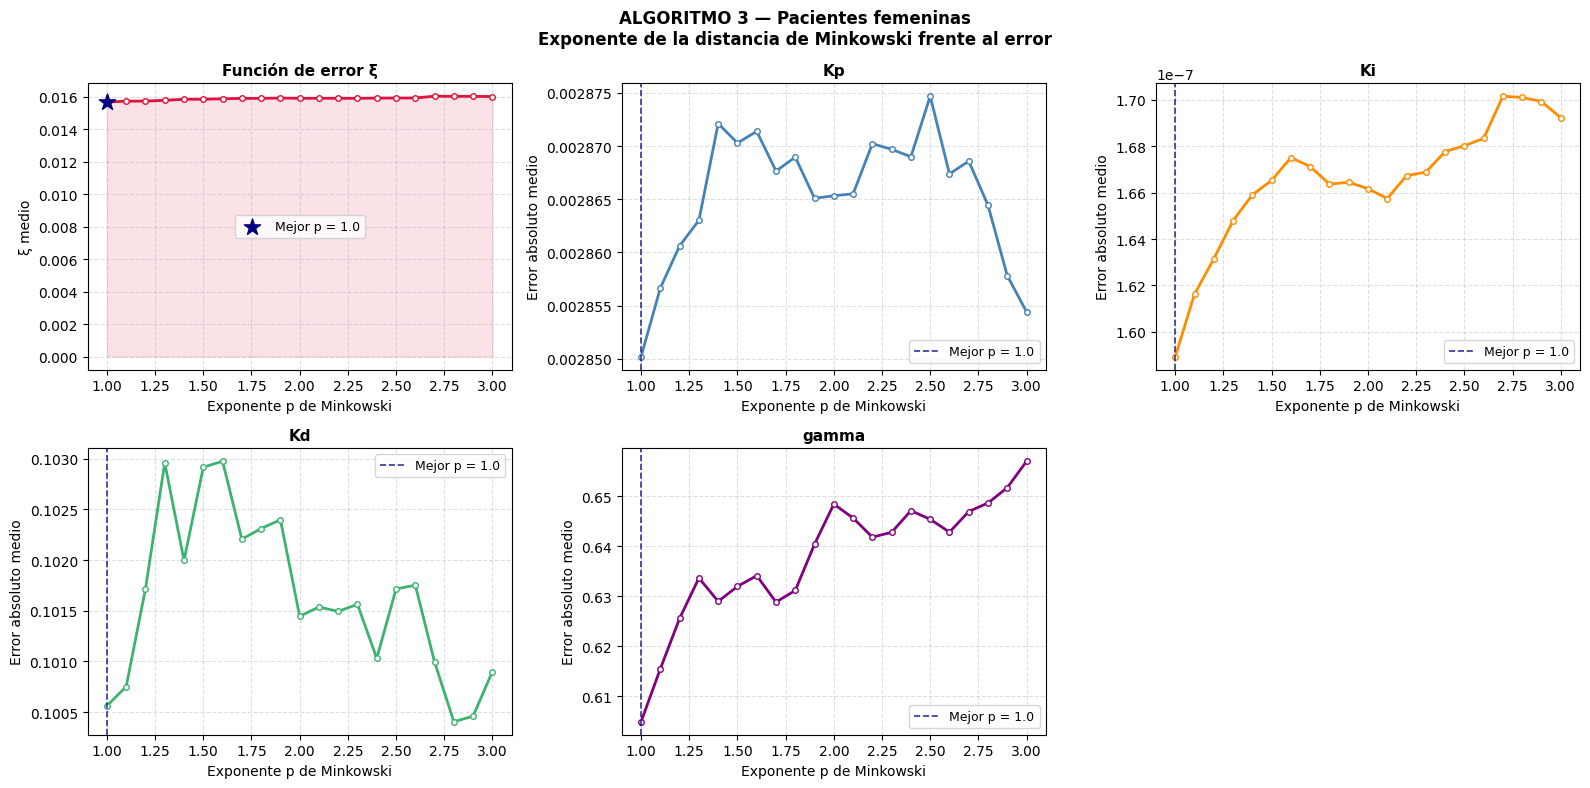

[INFO] Guardada: C:\Users\yordi\Desktop\knn_alg3_barrido_p.png


In [14]:
# =============================================================================
# FIGURA — ALGORITMO 3 — Pacientes femeninas
# EXPONENTE DE MINKOWSKI FRENTE AL ERROR
# =============================================================================

# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_mujeres                       # ← Resultado del algoritmo a representar

TITULO      = ("ALGORITMO 3 — Pacientes femeninas\n"
               "Exponente de la distancia de Minkowski frente al error")
FIGSIZE     = (16, 8)                    # ← Tamaño de la figura (ancho, alto)
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "knn_alg3_barrido_p.png"    # ← Nombre del archivo PNG

COLOR_XI       = "crimson"        # ← Color de la curva de ξ
COLOR_MEJOR    = "navy"           # ← Color del marcador del mejor exponente
COLORES_HIPER  = ["steelblue", "darkorange",
                  "mediumseagreen", "purple"]   # ← Un color por hiperparámetro

ANCHO_LINEA    = 2.0              # ← Grosor de las curvas
TAM_MARCADOR   = 4                # ← Tamaño de los marcadores
ALPHA_RELLENO  = 0.12             # ← Opacidad del relleno bajo la curva de ξ
TAM_TITULO     = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS  = 10               # ← Tamaño de fuente de los ejes
TAM_LEYENDA    = 9                # ← Tamaño de fuente de la leyenda
ALPHA_REJILLA  = 0.4              # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

tabla    = RES["tabla_p"]
p_vals   = tabla["p"].to_numpy()
mejor_p  = RES["mejor_p"]
idx_best = int(np.argmin(np.abs(p_vals - mejor_p)))

fig, ejes = plt.subplots(2, 3, figsize=FIGSIZE)
fig.suptitle(TITULO, fontsize=TAM_TITULO, fontweight="bold")
ejes_planos = ejes.flatten()

# ── Panel principal: función de error ξ ──────────────────────────────────────
ax = ejes_planos[0]
xi_vals = tabla["xi medio"].to_numpy()
ax.plot(p_vals, xi_vals, color=COLOR_XI, lw=ANCHO_LINEA,
        marker="o", ms=TAM_MARCADOR, markerfacecolor="white")
ax.fill_between(p_vals, xi_vals, alpha=ALPHA_RELLENO, color=COLOR_XI)
ax.scatter([mejor_p], [xi_vals[idx_best]], s=150, marker="*",
           color=COLOR_MEJOR, zorder=5,
           label=f"Mejor p = {mejor_p}")
ax.set_xlabel("Exponente p de Minkowski", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("ξ medio", fontsize=TAM_ETIQUETAS)
ax.set_title("Función de error ξ", fontsize=TAM_ETIQUETAS + 1, fontweight="bold")
ax.legend(fontsize=TAM_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# ── Paneles por hiperparámetro: error absoluto medio ─────────────────────────
for j, nombre_h in enumerate(COLS_HIPER):
    ax = ejes_planos[j + 1]
    valores = tabla[f"EAM {nombre_h}"].to_numpy()
    ax.plot(p_vals, valores, color=COLORES_HIPER[j % len(COLORES_HIPER)],
            lw=ANCHO_LINEA, marker="o", ms=TAM_MARCADOR,
            markerfacecolor="white")
    ax.axvline(mejor_p, color=COLOR_MEJOR, ls="--", lw=1.2, alpha=0.8,
               label=f"Mejor p = {mejor_p}")
    ax.set_xlabel("Exponente p de Minkowski", fontsize=TAM_ETIQUETAS)
    ax.set_ylabel(f"Error absoluto medio", fontsize=TAM_ETIQUETAS)
    ax.set_title(nombre_h, fontsize=TAM_ETIQUETAS + 1, fontweight="bold")
    ax.legend(fontsize=TAM_LEYENDA)
    ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

ejes_planos[5].set_visible(False)   # Panel sobrante

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


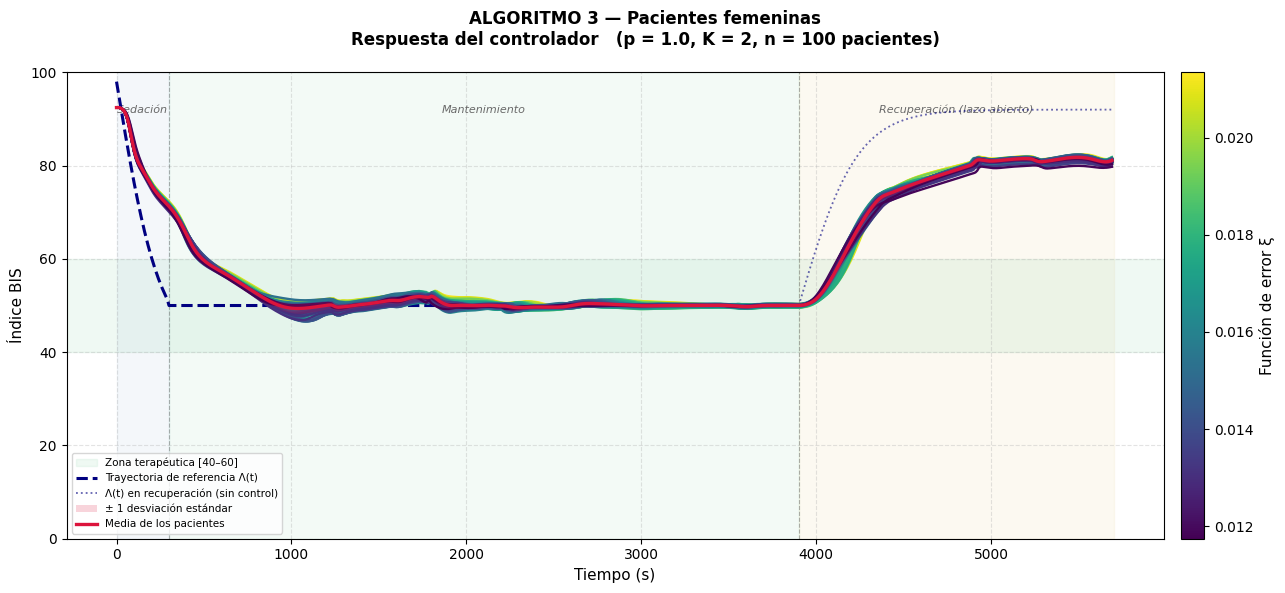

[INFO] Guardada: C:\Users\yordi\Desktop\knn_alg3_trayectoria.png


In [15]:
# =============================================================================
# FIGURA — ALGORITMO 3 — Pacientes femeninas
# RESPUESTA DEL CONTROLADOR SOBRE LA TRAYECTORIA CLÍNICA
# =============================================================================

# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
RES = resultado_mujeres                       # ← Resultado del algoritmo a representar


TITULO_BASE = "ALGORITMO 3 — Pacientes femeninas"
FIGSIZE     = (13, 6)                    # ← Tamaño de la figura
DPI_GUARDA  = 150                        # ← Resolución del archivo
ARCHIVO     = "knn_alg3_trayectoria.png"   # ← Nombre del archivo PNG
COLORMAP    = "viridis"                # ← Mapa de color asociado a ξ 
INVERTIR_COLORMAP = False              # ← Invertir el sentido del mapa de color
LIMITES_COLOR     = None               # ← (mín, máx) de ξ en la barra; None = automático
ETIQUETA_BARRA    = "Función de error ξ"   # ← Rótulo de la barra de color
TAM_BARRA         = 0.035              # ← Anchura relativa de la barra de color
SEPARACION_BARRA  = 0.015              # ← Separación entre el eje y la barra de color

COLOR_REFERENCIA = "navy"        # ← Color de la trayectoria de referencia
ESTILO_REFERENCIA = "--"         # ← Estilo de línea de la referencia
ANCHO_REFERENCIA = 2.2           # ← Grosor de la referencia
ANCHO_PACIENTE   = 1.7           # ← Grosor de las curvas de cada paciente

# Media de las trayectorias de todos los pacientes y franja de dispersión
MOSTRAR_MEDIA  = True            # ← Superponer la media de las trayectorias
COLOR_MEDIA    = "crimson"       # ← Color de la media y de la franja
ANCHO_MEDIA    = 2.4             # ← Grosor de la curva de la media
ESTILO_MEDIA   = "-"             # ← Estilo de línea de la media
ETIQUETA_MEDIA = "Media de los pacientes"   # ← Rótulo de la media en la leyenda
MOSTRAR_BANDA  = True            # ← Mostrar la franja de ± k desviaciones estándar
K_DESVIACIONES = 1.0             # ← Número k de desviaciones estándar de la franja
ALPHA_BANDA    = 0.18            # ← Opacidad de la franja

COLOR_ZONA   = "mediumseagreen"  # ← Color de la zona terapéutica
ALPHA_ZONA   = 0.08              # ← Opacidad de la zona terapéutica
ZONA_INF, ZONA_SUP = 40, 60      # ← Límites de la zona terapéutica

# Colores y opacidad de las bandas que delimitan las tres fases clínicas
COLOR_FASE_SEDACION      = "steelblue"
COLOR_FASE_MANTENIMIENTO = "mediumseagreen"
COLOR_FASE_RECUPERACION  = "goldenrod"
ALPHA_FASES  = 0.06
MOSTRAR_ETIQUETAS_FASE = True    # ← Mostrar los rótulos de cada fase

LIMITES_Y     = (0, 100)         # ← Límites del eje vertical
TAM_TITULO    = 12               # ← Tamaño de fuente del título
TAM_ETIQUETAS = 11               # ← Tamaño de fuente de los ejes
TAM_LEYENDA   = 7.5              # ← Tamaño de fuente de la leyenda (referencia y zona terapéutica)
POSICION_LEYENDA = "lower left"  # ← Posición de la leyenda
ALPHA_REJILLA = 0.35             # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

xi_vals = RES["xi"]
bis     = RES["bis"]
df_alg  = RES["df"]

# Se representan todos los pacientes, ordenados de forma ascendente por ξ
n_sel   = len(xi_vals)
idx_sel = np.argsort(xi_vals)

# ── Asignación del color de cada respuesta en función de su valor de ξ ───────
mapa = mpl.colormaps[COLORMAP]
if INVERTIR_COLORMAP:
    mapa = mapa.reversed()
xi_pacientes = xi_vals[idx_sel]
if LIMITES_COLOR is not None:
    v_min, v_max = LIMITES_COLOR
else:
    v_min, v_max = float(xi_pacientes.min()), float(xi_pacientes.max())
if v_max <= v_min:                       # Evita un intervalo de color nulo
    v_max = v_min + 1e-12
norma = mpl.colors.Normalize(vmin=v_min, vmax=v_max)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.suptitle(
    f"{TITULO_BASE}\n"
    f"Respuesta del controlador   "
    f"(p = {RES['mejor_p']}, K = {RES['k']}, n = {n_sel} pacientes)",
    fontsize=TAM_TITULO, fontweight="bold"
)

# Bandas de las tres fases clínicas
t_s2 = T_SEDACION
t_m2 = T_SEDACION + T_MANTENIMIENTO
t_r2 = N_TOT * DT
ax.axvspan(0,    t_s2, alpha=ALPHA_FASES, color=COLOR_FASE_SEDACION,      zorder=0)
ax.axvspan(t_s2, t_m2, alpha=ALPHA_FASES, color=COLOR_FASE_MANTENIMIENTO, zorder=0)
ax.axvspan(t_m2, t_r2, alpha=ALPHA_FASES, color=COLOR_FASE_RECUPERACION,  zorder=0)
for t_lim in (t_s2, t_m2):
    ax.axvline(t_lim, color="dimgray", lw=0.8, ls="--", alpha=0.5)

if MOSTRAR_ETIQUETAS_FASE:
    y_etiqueta = LIMITES_Y[0] + 0.93 * (LIMITES_Y[1] - LIMITES_Y[0])
    for medio, rotulo in [(t_s2 / 2, "Sedación"),
                          ((t_s2 + t_m2) / 2, "Mantenimiento"),
                          ((t_m2 + t_r2) / 2, "Recuperación (lazo abierto)")]:
        ax.text(medio, y_etiqueta, rotulo, ha="center", va="top",
                fontsize=8, color="dimgray", style="italic")

# Zona terapéutica y trayectoria de referencia
ax.axhspan(ZONA_INF, ZONA_SUP, alpha=ALPHA_ZONA, color=COLOR_ZONA,
           label=f"Zona terapéutica [{ZONA_INF}–{ZONA_SUP}]", zorder=0)
ax.plot(EJE_T[:N_CTRL + 1], LAMBDA_REF[:N_CTRL + 1], color=COLOR_REFERENCIA,
        lw=ANCHO_REFERENCIA, ls=ESTILO_REFERENCIA,
        label="Trayectoria de referencia Λ(t)", zorder=3)
# En la recuperación el controlador permanece desactivado; Λ(t) se muestra
# únicamente como curva de comparación
ax.plot(EJE_T[N_CTRL:], LAMBDA_REF[N_CTRL:], color=COLOR_REFERENCIA,
        lw=0.6 * ANCHO_REFERENCIA, ls=":", alpha=0.6,
        label="Λ(t) en recuperación (sin control)", zorder=3)

# Curvas de todos los pacientes, coloreadas según su valor de ξ. 
for idx in idx_sel[::-1]:
    ax.plot(EJE_T, bis[idx], color=mapa(norma(xi_vals[idx])),
            lw=ANCHO_PACIENTE, zorder=4)

# Media de las trayectorias de todos los pacientes y franja de ± k desviaciones
# estándar. La desviación estándar se calcula con corrección de Bessel
# (ddof = 1), por tratarse de una estimación a partir de una muestra.
if MOSTRAR_MEDIA:
    bis_pacientes = bis[idx_sel]
    media_bis   = bis_pacientes.mean(axis=0)
    if MOSTRAR_BANDA and n_sel > 1:
        desv_bis = K_DESVIACIONES * bis_pacientes.std(axis=0, ddof=1)
        ax.fill_between(EJE_T, media_bis - desv_bis, media_bis + desv_bis,
                        color=COLOR_MEDIA, alpha=ALPHA_BANDA, lw=0, zorder=5,
                        label=f"± {K_DESVIACIONES:g} desviación estándar")
    ax.plot(EJE_T, media_bis, color=COLOR_MEDIA, lw=ANCHO_MEDIA,
            ls=ESTILO_MEDIA, label=ETIQUETA_MEDIA, zorder=6)

ax.set_xlabel("Tiempo (s)", fontsize=TAM_ETIQUETAS)
ax.set_ylabel("Índice BIS", fontsize=TAM_ETIQUETAS)
ax.set_ylim(*LIMITES_Y)
ax.legend(fontsize=TAM_LEYENDA, loc=POSICION_LEYENDA)
ax.grid(True, ls="--", alpha=ALPHA_REJILLA)

# Barra de color que relaciona cada tono con el valor de ξ del paciente
barra = fig.colorbar(mpl.cm.ScalarMappable(norm=norma, cmap=mapa), ax=ax,
                     fraction=TAM_BARRA, pad=SEPARACION_BARRA)
barra.set_label(ETIQUETA_BARRA, fontsize=TAM_ETIQUETAS)

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")


## Etapa 8: Comparación entre los tres algoritmos

In [16]:
# =============================================================================
# TABLA COMPARATIVA — MEDIA Y DESVIACIÓN ESTÁNDAR DE LA FUNCIÓN DE ERROR ξ
# =============================================================================
#
# OBSERVACIÓN METODOLÓGICA: los algoritmos 2 y 3 operan sobre subconjuntos
# disjuntos del mismo conjunto de pacientes empleado por el algoritmo 1. En
# consecuencia, las tres muestras no son estadísticamente independientes entre
# sí, circunstancia que conviene tener presente al interpretar las pruebas
# inferenciales que se presentan más adelante.

resultados_todos = [resultado_global, resultado_hombres, resultado_mujeres]

etiquetas_algoritmos = [
    "Alg. 1 — Global",
    "Alg. 2 — Hombres",
    "Alg. 3 — Mujeres",
]

registros_comparacion = []
for etiqueta, res in zip(etiquetas_algoritmos, resultados_todos):
    x = res["xi"]
    registros_comparacion.append({
        "Algoritmo"      : etiqueta,
        "n pacientes"    : len(x),
        "K"              : res["k"],
        "Mejor p"        : res["mejor_p"],
        "ξ medio"        : float(np.mean(x)),
        "ξ desv. estándar": float(np.std(x, ddof=1)) if len(x) > 1 else np.nan,
        "ξ mediana"      : float(np.median(x)),
        "ξ mínimo"       : float(np.min(x)),
        "ξ máximo"       : float(np.max(x)),
    })

df_comparacion = pd.DataFrame(registros_comparacion)

ancho = 92
print("=" * ancho)
print("  TABLA COMPARATIVA — FUNCIÓN DE ERROR ξ DE LOS TRES ALGORITMOS")
print("  ξ = (2/T_c²) · ∫₀^T_c  t · |e(t) / Λ(t)| dt   (sedación y mantenimiento)")
print("=" * ancho)
print(f"  {'Algoritmo':<20} {'n':>4} {'K':>3} {'p':>6} "
      f"{'Media':>11} {'Desv.est.':>11} {'Mediana':>11} {'Mín':>10} {'Máx':>10}")
print("  " + "─" * (ancho - 4))
for _, f in df_comparacion.iterrows():
    desv = f["ξ desv. estándar"]
    desv_txt = f"{desv:>11.6f}" if not np.isnan(desv) else f"{'n/d':>11}"
    print(f"  {f['Algoritmo']:<20} {int(f['n pacientes']):>4} {int(f['K']):>3} "
          f"{f['Mejor p']:>6.2f} {f['ξ medio']:>11.6f} {desv_txt} "
          f"{f['ξ mediana']:>11.6f} {f['ξ mínimo']:>10.6f} "
          f"{f['ξ máximo']:>10.6f}")
print("=" * ancho)

idx_menor = int(df_comparacion["ξ medio"].idxmin())
algoritmo_menor = df_comparacion.loc[idx_menor, "Algoritmo"]
print(f"  Menor ξ medio: {algoritmo_menor}  "
      f"({df_comparacion.loc[idx_menor, 'ξ medio']:.6f})")
print("=" * ancho)

try:
    display(df_comparacion)
except NameError:
    print(df_comparacion.to_string(index=False))


# =============================================================================
# EXPORTACIÓN DEL BARRIDO SOBRE EL EXPONENTE DE MINKOWSKI
# =============================================================================
# Se registra, para cada variante y cada valor de p, el número de pacientes
# estimados, la media, la desviación estándar y el mínimo de ξ, así como el
# error absoluto medio de cada hiperparámetro respecto a la sintonización
# mediante Algoritmo Genético.

RUTA_BARRIDO_P = "Barrido_p_KNN.csv"
nombres_variante = ["Global", "Hombres", "Mujeres"]
tablas_barrido = []
for nombre_v, res in zip(nombres_variante, resultados_todos):
    t_v = res["tabla_p"].rename(columns={
        "xi medio": "xi_media", "xi desv.est.": "xi_desv_est",
        "xi mínimo": "xi_minimo", "EAM Kp": "EAM_Kp", "EAM Ki": "EAM_Ki",
        "EAM Kd": "EAM_Kd", "EAM gamma": "EAM_rho"})
    t_v.insert(0, "Variante", nombre_v)
    t_v.insert(1, "n_pacientes", len(res["xi"]))
    tablas_barrido.append(t_v)
pd.concat(tablas_barrido, ignore_index=True).to_csv(RUTA_BARRIDO_P, index=False)
print(f"[INFO] Barrido sobre p guardado en: {RUTA_BARRIDO_P}")


  TABLA COMPARATIVA — FUNCIÓN DE ERROR ξ DE LOS TRES ALGORITMOS
  ξ = (2/T_c²) · ∫₀^T_c  t · |e(t) / Λ(t)| dt   (sedación y mantenimiento)
  Algoritmo               n   K      p       Media   Desv.est.     Mediana        Mín        Máx
  ────────────────────────────────────────────────────────────────────────────────────────
  Alg. 1 — Global       200   2   1.00    0.016219    0.002912    0.015629   0.011706   0.035031
  Alg. 2 — Hombres      100   2   2.20    0.016651    0.003046    0.015927   0.012124   0.034549
  Alg. 3 — Mujeres      100   2   1.00    0.015681    0.002049    0.014985   0.011742   0.021345
  Menor ξ medio: Alg. 3 — Mujeres  (0.015681)


,Algoritmo,n pacientes,K,Mejor p,ξ medio,ξ desv. estándar,ξ mediana,ξ mínimo,ξ máximo
0,Alg. 1 — Global,200,2,1.0,0.016219,0.002912,0.015629,0.011706,0.035031
1,Alg. 2 — Hombres,100,2,2.2,0.016651,0.003046,0.015927,0.012124,0.034549
2,Alg. 3 — Mujeres,100,2,1.0,0.015681,0.002049,0.014985,0.011742,0.021345


[INFO] Barrido sobre p guardado en: Barrido_p_KNN.csv


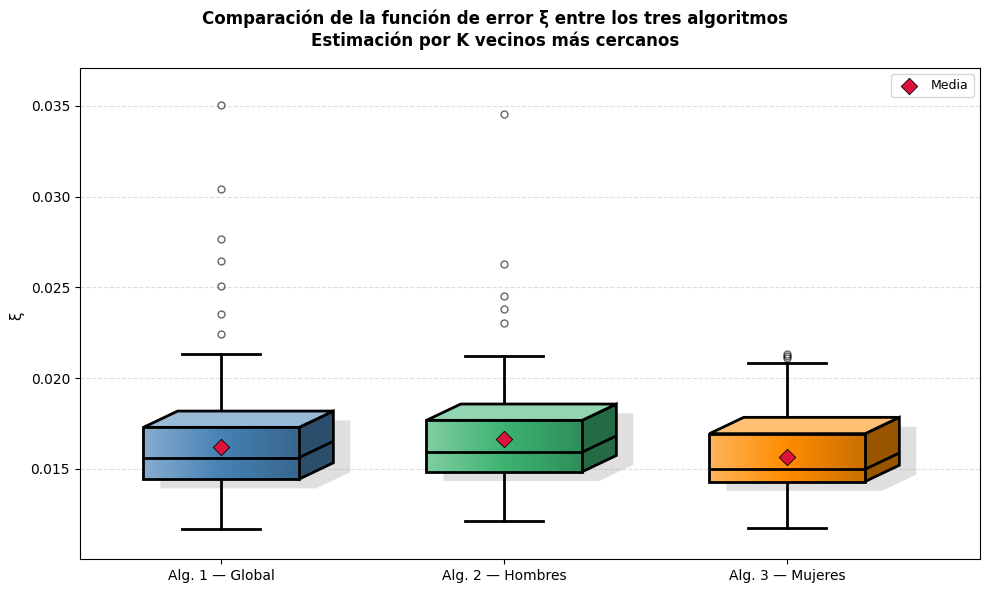

[INFO] Guardada: C:\Users\yordi\Desktop\knn_boxplot_comparativo.png


In [17]:
# =============================================================================
# FIGURA — DIAGRAMA DE CAJA COMPARATIVO DE LA FUNCIÓN DE ERROR ξ
# =============================================================================
#
# Cada caja se dibuja con relieve de apariencia tridimensional. Para ello, a
# la cara frontal (el rectángulo convencional del diagrama, delimitado por el
# primer y el tercer cuartil) se le añaden una cara lateral oscurecida y una
# cara superior aclarada, desplazadas en diagonal para simular profundidad, así
# como un degradado de iluminación y una sombra proyectada. El relieve es
# exclusivamente estético: la escala vertical, los cuartiles, la mediana y los
# bigotes se leen sobre la cara frontal.
# ── CONFIGURACIÓN DE DISEÑO ──────────────────────────────────────────────────
TITULO = ("Comparación de la función de error ξ entre los tres algoritmos\n"
          "Estimación por K vecinos más cercanos")
FIGSIZE    = (10, 6)                       # ← Tamaño de la figura
DPI_GUARDA = 150                           # ← Resolución del archivo
ARCHIVO    = "knn_boxplot_comparativo.png" # ← Nombre del archivo PNG

COLORES_CAJAS = ["steelblue", "mediumseagreen", "darkorange"]  # ← Un color por caja
ALPHA_CAJAS   = 1.0         # ← Opacidad de las caras de las cajas
ANCHO_CAJAS   = 0.55        # ← Anchura de las cajas
COLOR_BORDE   = "black"     # ← Color de las aristas, bigotes y topes
ANCHO_BORDE   = 2.0         # ← Grosor de las aristas, bigotes y topes

# Relieve tridimensional
PROFUNDIDAD_X = 0.22        # ← Profundidad horizontal (fracción de la anchura de la caja)
PROFUNDIDAD_Y = 0.035       # ← Profundidad vertical (fracción del rango del eje vertical)
FACTOR_SOMBRA = 0.40        # ← Oscurecimiento de la cara lateral (0 = sin cambio, 1 = negro)
FACTOR_LUZ    = 0.45        # ← Aclarado de la cara superior (0 = sin cambio, 1 = blanco)

DEGRADADO_FRONTAL    = True # ← Aplicar degradado de iluminación a la cara frontal
INTENSIDAD_DEGRADADO = 0.35 # ← Intensidad del degradado (0 = color uniforme)

MOSTRAR_SOMBRA = True       # ← Dibujar la sombra proyectada detrás de cada caja
COLOR_SOMBRA   = "gray"     # ← Color de la sombra proyectada
ALPHA_SOMBRA   = 0.25       # ← Opacidad de la sombra proyectada
DESPLAZAMIENTO_SOMBRA = (0.06, 0.02)  # ← Desplazamiento (horizontal en unidades del
                                      #   eje, vertical como fracción de su rango)

COLOR_MEDIANA = "black"     # ← Color de la línea de la mediana
ANCHO_MEDIANA = 2           # ← Grosor de la línea de la mediana

MOSTRAR_MEDIA = True        # ← Marcar la media de cada grupo
COLOR_MEDIA   = "crimson"   # ← Color del marcador de la media
MARCADOR_MEDIA = "D"        # ← Símbolo del marcador de la media
TAM_MEDIA     = 70          # ← Tamaño del marcador de la media

ETIQUETA_Y    = "ξ "
TAM_TITULO    = 12          # ← Tamaño de fuente del título
TAM_ETIQUETAS = 11          # ← Tamaño de fuente de los ejes
TAM_LEYENDA   = 9           # ← Tamaño de fuente de la leyenda
ALPHA_REJILLA = 0.4         # ← Opacidad de la rejilla
# ──────────────────────────────────────────────────────────────────────────────

from matplotlib.patches import Polygon


def mezclar_color(color, destino, factor):
    """
    Interpola linealmente un color hacia otro color de destino. Se emplea
    para aclarar (destino blanco) u oscurecer (destino negro) las caras de las
    cajas y producir así el efecto de iluminación.

    Parámetros
    ----------
    color   : color de partida, en cualquier formato válido de Matplotlib
    destino : color hacia el cual se desplaza el color de partida
    factor  : proporción del desplazamiento (0 = sin cambio, 1 = destino)

    Retorna
    -------
    Tupla RGB con el color resultante
    """
    c = np.array(mpl.colors.to_rgb(color))
    d = np.array(mpl.colors.to_rgb(destino))
    return tuple(c + (d - c) * float(np.clip(factor, 0.0, 1.0)))


datos_boxplot = [res["xi"] for res in resultados_todos]
n_cajas       = len(datos_boxplot)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.suptitle(TITULO, fontsize=TAM_TITULO, fontweight="bold")
ax.set_axisbelow(True)

cajas = ax.boxplot(
    datos_boxplot,
    patch_artist=True,
    widths=ANCHO_CAJAS,
    medianprops=dict(color=COLOR_MEDIANA, lw=ANCHO_MEDIANA, zorder=6),
    whiskerprops=dict(color=COLOR_BORDE, lw=ANCHO_BORDE, zorder=2),
    capprops=dict(color=COLOR_BORDE, lw=ANCHO_BORDE, zorder=2),
    flierprops=dict(marker="o", markersize=5, alpha=0.6, zorder=2),
)

ax.set_xticks(np.arange(1, n_cajas + 1))
ax.set_xticklabels(etiquetas_algoritmos)

# Dimensiones del relieve expresadas en unidades de datos
y_min, y_max = ax.get_ylim()
rango_y = y_max - y_min
dx = PROFUNDIDAD_X * ANCHO_CAJAS
dy = PROFUNDIDAD_Y * rango_y
sx = DESPLAZAMIENTO_SOMBRA[0]
sy = DESPLAZAMIENTO_SOMBRA[1] * rango_y

for k, parche in enumerate(cajas["boxes"]):
    color = COLORES_CAJAS[k % len(COLORES_CAJAS)]
    vertices = parche.get_path().vertices
    x0, x1 = float(vertices[:, 0].min()), float(vertices[:, 0].max())
    y0, y1 = float(vertices[:, 1].min()), float(vertices[:, 1].max())

    # ── Sombra proyectada: silueta completa de la caja, desplazada ──────────
    if MOSTRAR_SOMBRA:
        silueta = [(x0, y0), (x1, y0), (x1 + dx, y0 + dy), (x1 + dx, y1 + dy),
                   (x0 + dx, y1 + dy), (x0, y1)]
        silueta = [(x + sx, y - sy) for x, y in silueta]
        ax.add_patch(Polygon(silueta, closed=True, facecolor=COLOR_SOMBRA,
                             edgecolor="none", alpha=ALPHA_SOMBRA, zorder=1))

    # ── Cara lateral (derecha), oscurecida ──────────────────────────────────
    ax.add_patch(Polygon(
        [(x1, y0), (x1 + dx, y0 + dy), (x1 + dx, y1 + dy), (x1, y1)],
        closed=True, facecolor=mezclar_color(color, "black", FACTOR_SOMBRA),
        edgecolor=COLOR_BORDE, lw=ANCHO_BORDE, alpha=ALPHA_CAJAS, zorder=3))

    # ── Cara superior, aclarada ─────────────────────────────────────────────
    ax.add_patch(Polygon(
        [(x0, y1), (x0 + dx, y1 + dy), (x1 + dx, y1 + dy), (x1, y1)],
        closed=True, facecolor=mezclar_color(color, "white", FACTOR_LUZ),
        edgecolor=COLOR_BORDE, lw=ANCHO_BORDE, alpha=ALPHA_CAJAS, zorder=3))

    # ── Cara frontal, con degradado horizontal de iluminación ───────────────
    parche.set_edgecolor(COLOR_BORDE)
    parche.set_linewidth(ANCHO_BORDE)
    parche.set_zorder(5)
    if DEGRADADO_FRONTAL:
        claro  = mezclar_color(color, "white", INTENSIDAD_DEGRADADO)
        oscuro = mezclar_color(color, "black", INTENSIDAD_DEGRADADO * 0.6)
        mapa_degradado = mpl.colors.LinearSegmentedColormap.from_list(
            f"degradado_{k}", [claro, color, oscuro])
        imagen = ax.imshow(np.linspace(0, 1, 256)[None, :],
                           cmap=mapa_degradado, aspect="auto",
                           extent=(x0, x1, y0, y1), origin="lower",
                           alpha=ALPHA_CAJAS, zorder=4)
        imagen.set_clip_path(parche)
        parche.set_facecolor("none")
    else:
        parche.set_facecolor(color)
        parche.set_alpha(ALPHA_CAJAS)

    # ── Continuación de la mediana sobre la cara lateral ────────────────────
    mediana = float(cajas["medians"][k].get_ydata()[0])
    ax.plot([x1, x1 + dx], [mediana, mediana + dy], color=COLOR_MEDIANA,
            lw=ANCHO_MEDIANA, solid_capstyle="butt", zorder=6)

if MOSTRAR_MEDIA:
    for i, datos in enumerate(datos_boxplot, start=1):
        ax.scatter([i], [np.mean(datos)], marker=MARCADOR_MEDIA,
                   s=TAM_MEDIA, color=COLOR_MEDIA, edgecolor="black",
                   linewidth=0.6, zorder=7,
                   label="Media" if i == 1 else None)
    ax.legend(fontsize=TAM_LEYENDA, loc="upper right")

# Límites de los ejes: se restablecen tras dibujar el degradado y se amplían
# para dar cabida a la profundidad del relieve y a la sombra proyectada
ax.set_xlim(0.5, n_cajas + 0.5 + dx + (sx if MOSTRAR_SOMBRA else 0.0))
ax.set_ylim(y_min - (sy if MOSTRAR_SOMBRA else 0.0), y_max + dy)

ax.set_ylabel(ETIQUETA_Y, fontsize=TAM_ETIQUETAS)
ax.grid(True, axis="y", ls="--", alpha=ALPHA_REJILLA)

plt.tight_layout()
ruta = os.path.join(RUTA_GRAFICAS, ARCHIVO)
plt.savefig(ruta, dpi=DPI_GUARDA, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta}")
